In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
File_Path = 'Advertising.csv'
df = pd.read_csv(r'C:\Users\rajde\\'+File_Path)

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


- Unnamed: 0 column actually itelf makes no sense. we can consider it as week column, which might come into help in future to calculate the impact of any particular instance's previous week's sales

In [6]:
df_copy = df.copy()

In [7]:
df_copy.rename(columns={'Unnamed: 0': 'Week_Number'}, inplace=True)

In [8]:
df_copy.columns

Index(['Week_Number', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [9]:
df_copy.head()

,Week_Number,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


- We can chnge the week numbers into specific weeks starting from '8th January, 2022' As there are total 200 instances , so there will be almost 4 years' data coveed in this dataset.

In [10]:
start_date = pd.to_datetime("2022-01-08")

In [11]:
df_copy["Date"] = start_date + pd.to_timedelta(df_copy["Week_Number"] - 1, unit="W")

In [12]:
df_copy.head()

,Week_Number,TV,Radio,Newspaper,Sales,Date
0,1,230.1,37.8,69.2,22.1,2022-01-08
1,2,44.5,39.3,45.1,10.4,2022-01-15
2,3,17.2,45.9,69.3,9.3,2022-01-22
3,4,151.5,41.3,58.5,18.5,2022-01-29
4,5,180.8,10.8,58.4,12.9,2022-02-05


In [13]:
df_copy['Week_Number']= df_copy['Week_Number'].astype(str)
df_copy['Week_Number'] = 'Week'+'-'+df_copy['Week_Number']

In [14]:
df_copy.head()

,Week_Number,TV,Radio,Newspaper,Sales,Date
0,Week-1,230.1,37.8,69.2,22.1,2022-01-08
1,Week-2,44.5,39.3,45.1,10.4,2022-01-15
2,Week-3,17.2,45.9,69.3,9.3,2022-01-22
3,Week-4,151.5,41.3,58.5,18.5,2022-01-29
4,Week-5,180.8,10.8,58.4,12.9,2022-02-05


In [15]:
df_copy.drop(['Week_Number'], inplace=True, axis=1)
df_copy

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,2025-10-04
196,94.2,4.9,8.1,9.7,2025-10-11
197,177.0,9.3,6.4,12.8,2025-10-18
198,283.6,42.0,66.2,25.5,2025-10-25


- We have total 4 years of data

- Sales Column is the Target Column and TV, Radio, Newspaper these three columns are independent columns

### Univariate Analysis

In [16]:
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))
# sns.histplot(x='TV',data=df_copy,ax=axes[0], kde=True)

# sns.histplot(x='Radio',data=df_copy,ax=axes[1], kde=True)

# sns.histplot(x='Newspaper',data=df_copy,ax=axes[2], kde=True)

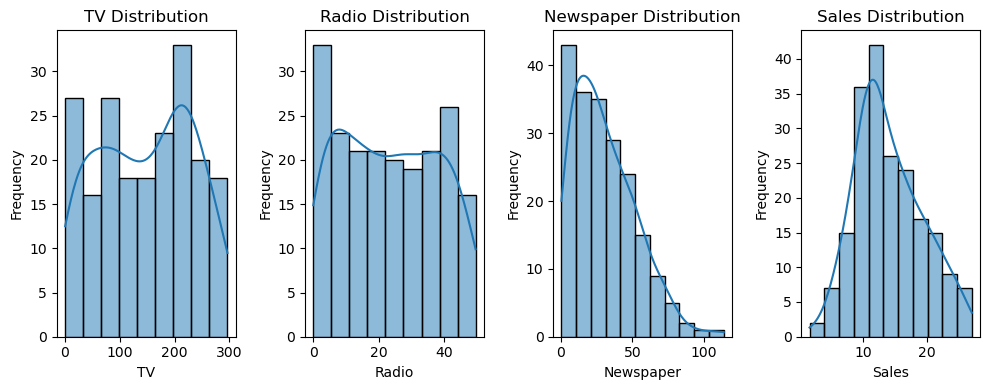

In [17]:
cols = ["TV", "Radio", "Newspaper","Sales"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(cols),
    figsize=(10, 4))

for ax, col in zip(axes, cols):
    sns.histplot(data=df_copy,x=col,kde=True,ax=ax)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

- The Target variable 'Sales' is normally distributed
- For TV and Radio we can say they are almost uniformly distributed
- Newspaper spend is right skewed

### Bivariate and Multivariate Analysis

In [18]:
# cols = ['TV','Radio','Newspaper','Sales']
# plt.figure(figsize=(8,4))
# for c in cols:
#     plt.plot(df_copy['Date'],df_copy[c],label=c)

# plt.xlabel("Date")

Text(0, 0.5, 'Newspaper Spend')

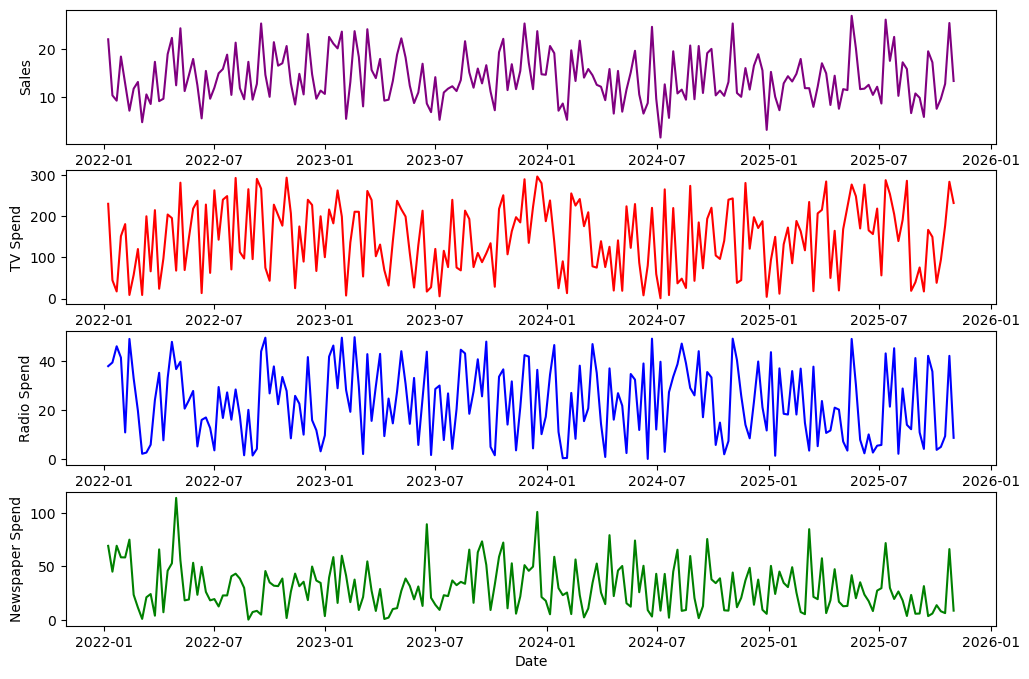

In [19]:
cols = ['TV','Radio','Newspaper','Sales']
fig, axes = plt.subplots(nrows=len(cols), ncols=1, figsize=(12, 8))

axes[0].plot(df_copy["Date"], df_copy["Sales"], label="Sales", color="purple")
axes[0].set_xlabel('Date')
axes[0].set_ylabel("Sales")

axes[1].plot(df_copy["Date"], df_copy["TV"], label="TV Spend", color="red")
axes[1].set_xlabel('Date')
axes[1].set_ylabel("TV Spend")

axes[2].plot(df_copy["Date"], df_copy["Radio"], label="Radio Spend", color="blue")
axes[2].set_xlabel('Date')
axes[2].set_ylabel("Radio Spend")

axes[3].plot(df_copy["Date"], df_copy["Newspaper"], label="Newspaper Spend", color="green")
axes[3].set_xlabel('Date')
axes[3].set_ylabel("Newspaper Spend")



- For a few point we can't find the seasonality in either channel.
- rom the graph it seems like, the impact of TV Spend on Sales pretty much higher than Radio Spend and Newspaper Spend.

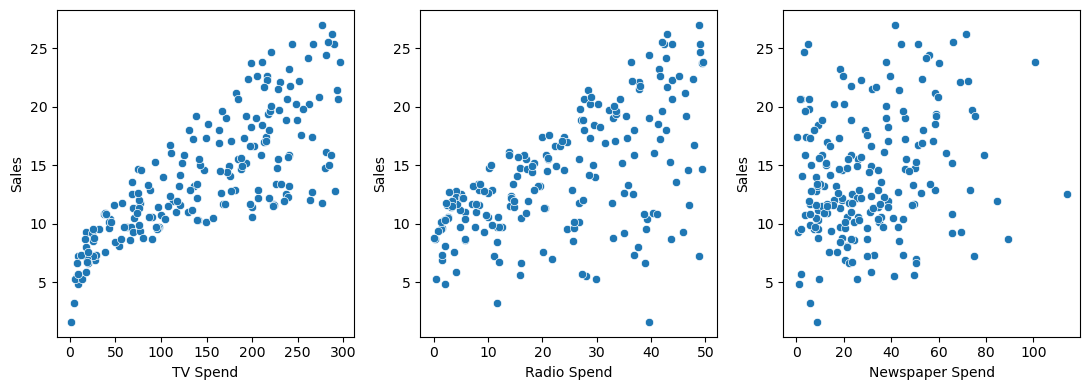

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=len(cols)-1, figsize=(11,4))

sns.scatterplot(x='TV',y='Sales',data=df_copy, ax=axes[0])
axes[0].set_xlabel('TV Spend')
axes[0].set_ylabel('Sales')

sns.scatterplot(x='Radio',y='Sales',data=df_copy, ax=axes[1])
axes[1].set_xlabel('Radio Spend')
axes[1].set_ylabel('Sales')

sns.scatterplot(x='Newspaper',y='Sales',data=df_copy, ax=axes[2])
axes[2].set_xlabel('Newspaper Spend')
axes[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

- It's very clearly noticable that TV Spend and Sales have strong linear relationship after a certain point. The linear relationship is maintained between Radio SPend and Sales as well.
- There is no linear relationship found between Newspaper Spendand Sales

### Checking the correlation

In [21]:
df_copy[['TV','Radio','Newspaper','Sales']].corr()['Sales'].sort_values(ascending=False)

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

<Axes: >

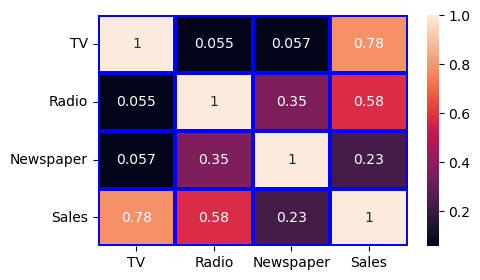

In [22]:
plt.figure(figsize=(5,3))
sns.heatmap(df_copy[['TV','Radio','Newspaper','Sales']].corr(),  annot=True,linecolor='blue',linewidth=1.5)

- TV Spend is highly correlated with Sales followed by Radio and Newspaper

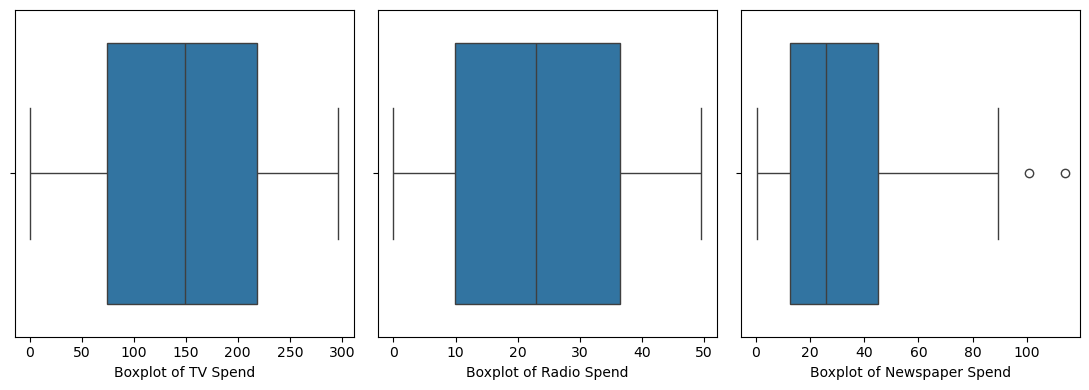

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=len(cols)-1, figsize=(11,4))

sns.boxplot(x='TV',data=df_copy, ax=axes[0])
axes[0].set_xlabel('Boxplot of TV Spend')

sns.boxplot(x='Radio',data=df_copy, ax=axes[1])
axes[1].set_xlabel('Boxplot of Radio Spend')

sns.boxplot(x='Newspaper',data=df_copy, ax=axes[2])
axes[2].set_xlabel('Boxplot of Newspaper Spend')

plt.tight_layout()
plt.show()

- There are only two outliers present for Newspaper spend. Let's identify thos

### Outlier Detection

In [24]:
outliers = []
upper_lim = 0
lower_lim = 0
def outlier_detection(df,x):
    global outliers
    x_dict = dict(df[x].describe())
    print(x_dict)
    Q1 = x_dict['25%']
    print("Q1 :", Q1)
    Q3 = x_dict['75%']
    print("Q3 :", Q3)
    IQR = Q3 - Q1
    print("Inter quartile range is ", IQR)
    global lower_lim
    global upper_lim
    lower_lim = Q1 - 1.5 * IQR
    upper_lim = Q3 + 1.5 * IQR
    print("The lower limit is ", round(lower_lim))
    print("The upper limit is ", round(upper_lim))
    #print("The Lower whisker is ", x_dict['min'])
    #print("The upper whisker is ", x_dict['max'])

    for i in df[x]:
        if ((i > upper_lim) | (i < lower_lim)):
            outliers.append(i)
#    print("The outliers of ", x ,"is :", outliers)

In [25]:
outlier_detection(df_copy, 'Newspaper')

{'count': 200.0, 'mean': 30.553999999999995, 'std': 21.778620838522833, 'min': 0.3, '25%': 12.75, '50%': 25.75, '75%': 45.1, 'max': 114.0}
Q1 : 12.75
Q3 : 45.1
Inter quartile range is  32.35
The lower limit is  -36
The upper limit is  94


In [26]:
len(outliers)

2

In [27]:
outliers

[114.0, 100.9]

In [28]:
df_copy[df_copy['Newspaper'] >= upper_lim]

,TV,Radio,Newspaper,Sales,Date
16,67.8,36.6,114.0,12.5,2022-04-30
101,296.4,36.3,100.9,23.8,2023-12-16


In [29]:
df_copy.loc[(df_copy['Newspaper'] >= upper_lim) & (df_copy['Newspaper'] <= max(df_copy['Newspaper']))]

,TV,Radio,Newspaper,Sales,Date
16,67.8,36.6,114.0,12.5,2022-04-30
101,296.4,36.3,100.9,23.8,2023-12-16


- Only 1% of the whole column is outlier. As of now we aren't imputing this value

### Train Test Split and Preprocessing

In [30]:
# from sklearn.model_selection import train_test_split

- Although we will not do random split here, since the dataset has datestamp. So, we are taking first 70% of it as train dataset and rest 30% of it as a test set. Random Splitting will mess up the order of the dates in the dataset

In [31]:
df_copy

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,2025-10-04
196,94.2,4.9,8.1,9.7,2025-10-11
197,177.0,9.3,6.4,12.8,2025-10-18
198,283.6,42.0,66.2,25.5,2025-10-25


In [32]:
df_copy = df_copy.sort_values('Date').reset_index(drop=True)
df_copy

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,2025-10-04
196,94.2,4.9,8.1,9.7,2025-10-11
197,177.0,9.3,6.4,12.8,2025-10-18
198,283.6,42.0,66.2,25.5,2025-10-25


In [33]:
train_df = df_copy.iloc[0: int(len(df_copy)*0.7)]

In [34]:
train_df

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05
...,...,...,...,...,...
135,48.3,47.0,8.5,11.6,2024-08-10
136,25.6,39.0,9.3,9.5,2024-08-17
137,273.7,28.9,59.7,20.8,2024-08-24
138,43.0,25.9,20.5,9.6,2024-08-31


In [35]:
test_df = df_copy.iloc[int(len(df_copy)*0.7) :]

In [36]:
test_df

,TV,Radio,Newspaper,Sales,Date
140,73.4,17.0,12.9,10.9,2024-09-14
141,193.7,35.4,75.6,19.2,2024-09-21
142,220.5,33.2,37.9,20.1,2024-09-28
143,104.6,5.7,34.4,10.4,2024-10-05
144,96.2,14.8,38.9,11.4,2024-10-12
145,140.3,1.9,9.0,10.3,2024-10-19
146,240.1,7.3,8.7,13.2,2024-10-26
147,243.2,49.0,44.3,25.4,2024-11-02
148,38.0,40.3,11.9,10.9,2024-11-09
149,44.7,25.8,20.6,10.1,2024-11-16


### Splitting train_df and test_df into x_Train, x_Test, y_train and y_Test

In [37]:
#### Splitting into x_train and y_train
x_train = train_df[['TV','Radio','Newspaper']]
y_train = train_df[['Sales']]

#### splitting into x_test and y_test
x_test = test_df[['TV','Radio','Newspaper']]
y_test = test_df[['Sales']]

In [38]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         140 non-null    float64
 1   Radio      140 non-null    float64
 2   Newspaper  140 non-null    float64
dtypes: float64(3)
memory usage: 3.4 KB


In [39]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   140 non-null    float64
dtypes: float64(1)
memory usage: 1.2 KB


- As we have all the numerical columns present in the train dataset, so we don't need to separate numerical and categorical columns. Also only preprocessing on Numerical columns will be enough. Preprocessing for categorical columns in not necessary.

### Numerical Columns Preprocessing: Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler() # Will standardize all the values to have a mean 0 and standard deviation 1)

In [42]:
x_train_num_scaled = scaler.fit_transform(x_train)

#### Converting the numpy array, received as the output of scaling done in the previous step, into a dataframe where 
#### the column names of the main dataframe is maintained
x_train_num_scaled_df = pd.DataFrame(x_train_num_scaled, columns = x_train.columns)

In [43]:
x_train_num_scaled_df.head()

,TV,Radio,Newspaper
0,0.998823,0.894869,1.635721
1,-1.148661,0.997229,0.563919
2,-1.464536,1.447612,1.640169
3,0.089382,1.133709,1.159859
4,0.428398,-0.947609,1.155412


#### Preprocessing on Test Set

In [44]:
#### Applying the scaler on the test set.
x_test_num_scaled = scaler.transform(x_test)

#### Creating the dataframe as done before in the case of train set.
x_test_num_scaled_df = pd.DataFrame(x_test_num_scaled, columns = x_test.columns)

#### Modelling

In [45]:
import statsmodels.api as sm

In [46]:
x_train_const = sm.add_constant(x_train_num_scaled_df)

x_train_const.head()

,const,TV,Radio,Newspaper
0,1.0,0.998823,0.894869,1.635721
1,1.0,-1.148661,0.997229,0.563919
2,1.0,-1.464536,1.447612,1.640169
3,1.0,0.089382,1.133709,1.159859
4,1.0,0.428398,-0.947609,1.155412


In [47]:
y_train.head()

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [48]:
x_test.head()

,TV,Radio,Newspaper
140,73.4,17.0,12.9
141,193.7,35.4,75.6
142,220.5,33.2,37.9
143,104.6,5.7,34.4
144,96.2,14.8,38.9


In [49]:
y_test.head()

,Sales
140,10.9
141,19.2
142,20.1
143,10.4
144,11.4


In [50]:
print("The datatype of x_train_const is: ",type(x_train_const))
print("The datatype of y_train is: ",type(y_train))

The datatype of x_train_const is:  <class 'pandas.core.frame.DataFrame'>
The datatype of y_train is:  <class 'pandas.core.frame.DataFrame'>


In [51]:
x_train_const.shape

(140, 4)

In [52]:
y_train.shape

(140, 1)

In [53]:
x_train_const.dtypes

const        float64
TV           float64
Radio        float64
Newspaper    float64
dtype: object

### OLS_1: First Model

In [54]:
ols_1 = sm.OLS(y_train, x_train_const).fit()

In [55]:
print(ols_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     381.2
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           5.60e-66
Time:                        09:03:01   Log-Likelihood:                -273.89
No. Observations:                 140   AIC:                             555.8
Df Residuals:                     136   BIC:                             567.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1479      0.147     96.400      0.0

- R-Squared -> 89.4%
- Adjusted R-Squared -> 89.1%
- Which means that, the model can explain 89.1% of the variability of the dataset.
- The feature 'Newspaper' has p-value > 0.05. We can tell that this feature is statistically insignificant. 
- Features like, TV and Radio are statistically significant as the p-value is < 0.05.
- I will drop the feature 'Newspaper' and rerun the model and check its interpretation.

#### Feature elimination

In [56]:
x_train_wo_Newspaper = x_train_num_scaled_df.drop(['Newspaper'], axis=1)
x_train_wo_Newspaper

,TV,Radio
0,0.998823,0.894869
1,-1.148661,0.997229
2,-1.464536,1.447612
3,0.089382,1.133709
4,0.428398,-0.947609
...,...,...
135,-1.104693,1.522676
136,-1.367344,0.976757
137,1.503297,0.287534
138,-1.166017,0.082814


In [57]:
#### Adding Constant

x_train_wo_newspaper_const = sm.add_constant(x_train_wo_Newspaper)
x_train_wo_newspaper_const.head()

,const,TV,Radio
0,1.0,0.998823,0.894869
1,1.0,-1.148661,0.997229
2,1.0,-1.464536,1.447612
3,1.0,0.089382,1.133709
4,1.0,0.428398,-0.947609


### OLS_2: Second Model

In [58]:
ols_2 = sm.OLS(y_train, x_train_wo_newspaper_const).fit()

print(ols_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     575.1
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           2.26e-67
Time:                        09:03:10   Log-Likelihood:                -273.98
No. Observations:                 140   AIC:                             554.0
Df Residuals:                     137   BIC:                             562.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1479      0.146     96.688      0.0

- We can see that, in this case the R-Squared value remains unchanged whereas Adjusted R-Squared value has been increased slightly being 89.2%.
- This means this model can explain 89.2% of the variability of the dataset.
- Along with that we can notice here all the independent variables (TV and Radio) are statistically significant having p-value < 0.05.
- I can use this model for predicting the test set.
- As there are only two independent variables, so checking for the VIF and selecting fatures using RFE is not needed.

- The Model Equation will be :
    Sales = 4.0671 * TV + 2.6083 * Radio + 14.1479

#### Predicting the Train Set

In [59]:
y_train

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
135,11.6
136,9.5
137,20.8
138,9.6


In [60]:
y_train_hat = ols_2.predict(x_train_wo_newspaper_const)
y_train_hat

0      20.544262
1      12.077234
2      11.967285
3      17.468451
4      13.418528
         ...    
135    13.626588
136    11.134436
137    21.011881
138     9.621565
139    19.502974
Length: 140, dtype: float64

In [61]:
y_train_hat.shape

(140,)

In [62]:
y_train.iloc[:,0]

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
135    11.6
136     9.5
137    20.8
138     9.6
139    20.7
Name: Sales, Length: 140, dtype: float64

In [63]:
train_df['Date']

0     2022-01-08
1     2022-01-15
2     2022-01-22
3     2022-01-29
4     2022-02-05
         ...    
135   2024-08-10
136   2024-08-17
137   2024-08-24
138   2024-08-31
139   2024-09-07
Name: Date, Length: 140, dtype: datetime64[ns]

#### Creating a Dataframe for Train Set - Date column, Actual Value, Predicted value and Error Values

In [64]:
concat_train_pred_df = pd.DataFrame({
    'Date':train_df['Date'],
    'Actual Value': y_train.iloc[:,0],
    'Predicted Value': y_train_hat})
concat_train_pred_df['Error'] = concat_train_pred_df['Actual Value']-concat_train_pred_df['Predicted Value']

In [65]:
concat_train_pred_df

,Date,Actual Value,Predicted Value,Error
0,2022-01-08,22.1,20.544262,1.555738
1,2022-01-15,10.4,12.077234,-1.677234
2,2022-01-22,9.3,11.967285,-2.667285
3,2022-01-29,18.5,17.468451,1.031549
4,2022-02-05,12.9,13.418528,-0.518528
...,...,...,...,...
135,2024-08-10,11.6,13.626588,-2.026588
136,2024-08-17,9.5,11.134436,-1.634436
137,2024-08-24,20.8,21.011881,-0.211881
138,2024-08-31,9.6,9.621565,-0.021565


#### Preprocessing on Test Set

In [66]:
y_test

,Sales
140,10.9
141,19.2
142,20.1
143,10.4
144,11.4
145,10.3
146,13.2
147,25.4
148,10.9
149,10.1


In [67]:
x_test_num_scaled_df.head(10)

,TV,Radio,Newspaper
0,-0.814274,-0.524521,-0.868115
1,0.577657,0.731093,1.920349
2,0.887746,0.580965,0.243713
3,-0.453274,-1.295632,0.088057
4,-0.550466,-0.674649,0.288186
5,-0.040207,-1.554944,-1.041561
6,1.114528,-1.186448,-1.054902
7,1.150397,1.659156,0.528341
8,-1.223869,1.065469,-0.912588
9,-1.146347,0.075990,-0.525672


In [68]:
x_test_num_scaled_wo_newspaper_df = x_test_num_scaled_df.drop(['Newspaper'], axis=1)
x_test_num_scaled_wo_newspaper_df.head()

,TV,Radio
0,-0.814274,-0.524521
1,0.577657,0.731093
2,0.887746,0.580965
3,-0.453274,-1.295632
4,-0.550466,-0.674649


In [69]:
x_test_num_scaled_wo_newspaper_const_df = sm.add_constant(x_test_num_scaled_wo_newspaper_df)
x_test_num_scaled_wo_newspaper_const_df.head()

,const,TV,Radio
0,1.0,-0.814274,-0.524521
1,1.0,0.577657,0.731093
2,1.0,0.887746,0.580965
3,1.0,-0.453274,-1.295632
4,1.0,-0.550466,-0.674649


#### Predicting Test Set

In [70]:
y_test_hat = ols_2.predict(x_test_num_scaled_wo_newspaper_const_df)
y_test_hat[:10]

0     9.468015
1    18.404162
2    19.273743
3     8.924933
4    10.149363
5     9.928547
6    15.586114
7    23.154226
8    11.949347
9     9.683765
dtype: float64

In [71]:
y_test_hat.index = y_test.index

#### Creating a Dataframe for Train Set - Date column, Actual Value, Predicted value and Error Values

In [72]:
concat_test_pred_df = pd.DataFrame({
    'Date':test_df['Date'],
    'Actual Value': y_test.iloc[:,0],
    'Predicted Value': y_test_hat})
concat_test_pred_df['Error'] = concat_test_pred_df['Actual Value']-concat_test_pred_df['Predicted Value']

In [73]:
concat_test_pred_df

,Date,Actual Value,Predicted Value,Error
140,2024-09-14,10.9,9.468015,1.431985
141,2024-09-21,19.2,18.404162,0.795838
142,2024-09-28,20.1,19.273743,0.826257
143,2024-10-05,10.4,8.924933,1.475067
144,2024-10-12,11.4,10.149363,1.250637
145,2024-10-19,10.3,9.928547,0.371453
146,2024-10-26,13.2,15.586114,-2.386114
147,2024-11-02,25.4,23.154226,2.245774
148,2024-11-09,10.9,11.949347,-1.049347
149,2024-11-16,10.1,9.683765,0.416235


### Residual Analysis for Train and Test Set for OLS_2 model

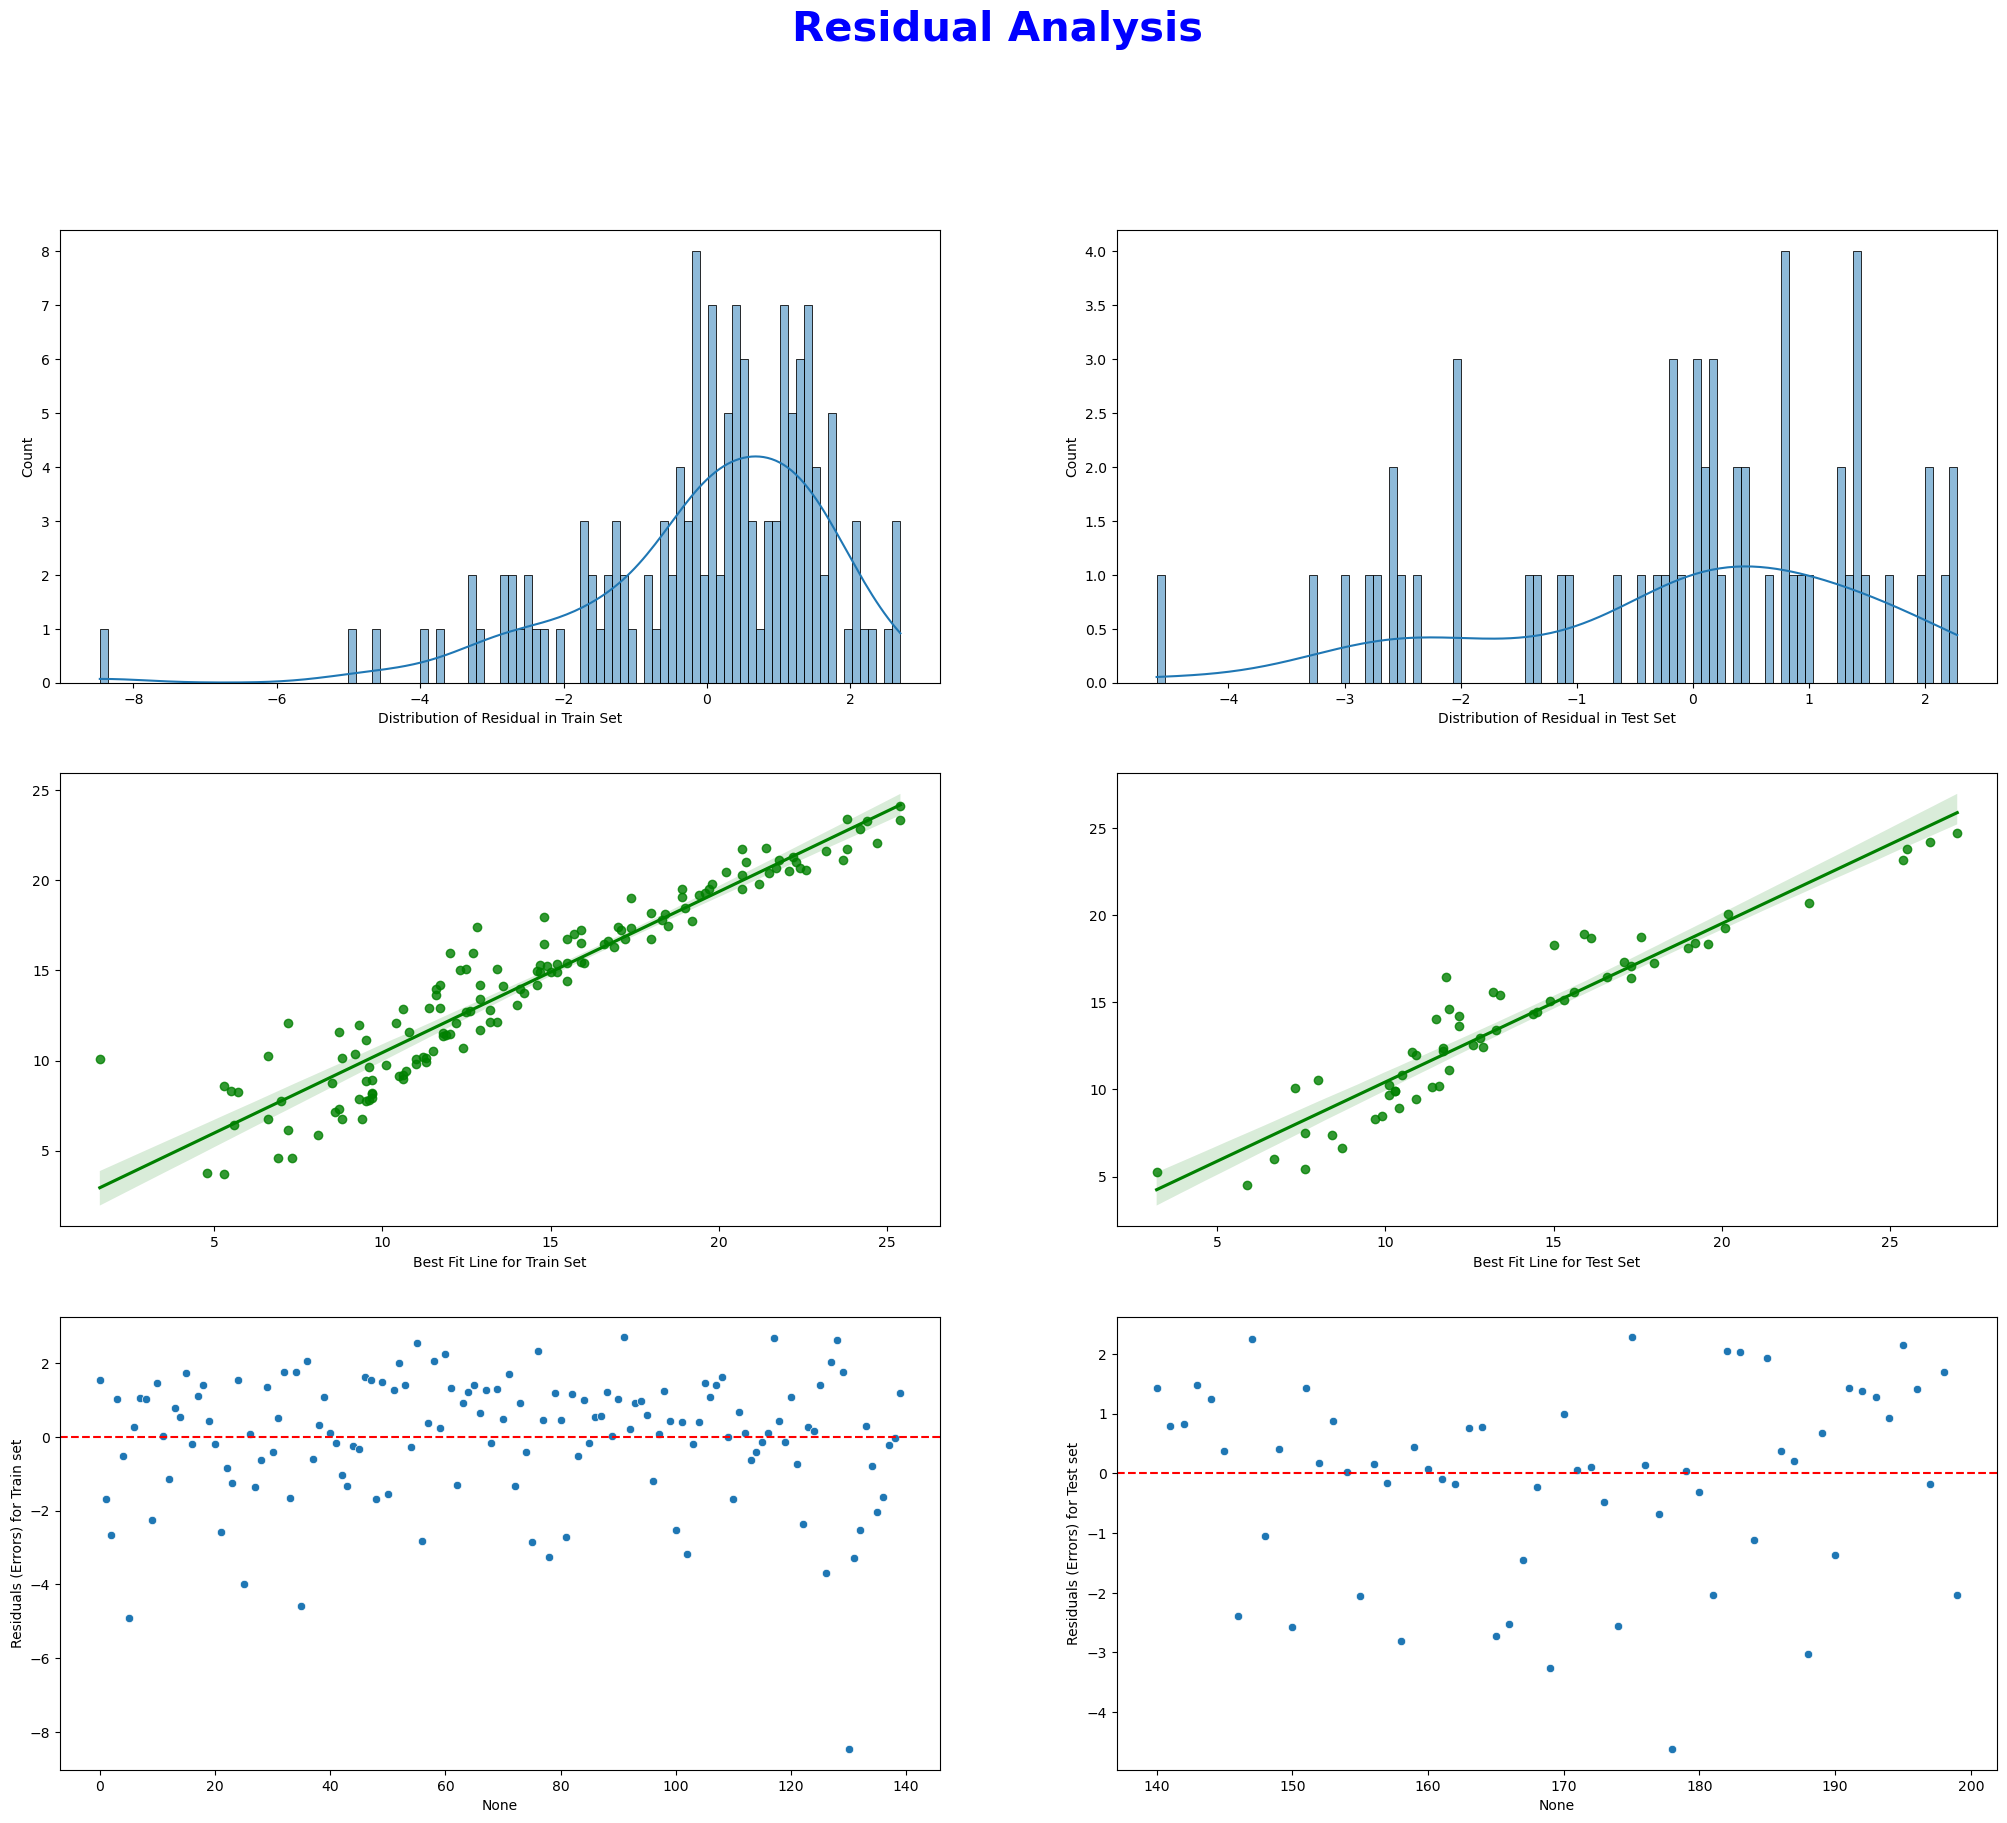

In [74]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25,20))

sns.histplot(x='Error', data=concat_train_pred_df, kde=True,bins=100, ax=axes[0,0])
axes[0,0].set_xlabel('Distribution of Residual in Train Set')

sns.histplot(x='Error', data=concat_test_pred_df, kde=True,bins=100, ax=axes[0,1])
axes[0,1].set_xlabel('Distribution of Residual in Test Set')

sns.regplot(x=y_train, y=y_train_hat, color='green', ax=axes[1,0])
axes[1,0].set_xlabel('Best Fit Line for Train Set')

sns.regplot(x=y_test, y=y_test_hat, color='green', ax=axes[1,1])
axes[1,1].set_xlabel('Best Fit Line for Test Set')

sns.scatterplot(x=concat_train_pred_df.index, y=concat_train_pred_df['Error'], data=concat_train_pred_df, ax=axes[2,0])
axes[2,0].axhline(y=0, color='r', linestyle='--')
axes[2,0].set_ylabel("Residuals (Errors) for Train set")


sns.scatterplot(x=concat_test_pred_df.index, y=concat_test_pred_df['Error'], data=concat_test_pred_df, ax=axes[2,1])
axes[2,1].axhline(y=0, color='r', linestyle='--')
axes[2,1].set_ylabel("Residuals (Errors) for Test set")

fig.suptitle("Residual Analysis", fontsize=30, fontweight='bold', color='blue',ha='center',va='center')
plt.show()

- Observation:
    - The distribution Residual for both Train and Test Set are showing a bit skewed nature - We might need to apply Box-Cox transformation on the numerical featuresto get rid of this.
    - Best Fit line seems to be fine for both train and test set.
    - The error values are homoscedastic (doesn't show any particular nature)

#### Checking RMSE Error

In [75]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [76]:
print("The train set R2 score: ", round(r2_score(y_train, y_train_hat)*100,2))

print("The test set R2 score: ", round(r2_score(y_test, y_test_hat)*100,2))

The train set R2 score:  89.36
The test set R2 score:  90.14


In [77]:
print("The train set RMSE is: ", np.sqrt(mean_squared_error(y_train, y_train_hat)))

print("The test set RMSE is: ", np.sqrt(mean_squared_error(y_test, y_test_hat)))

The train set RMSE is:  1.7126812399580391
The test set RMSE is:  1.5963945567674576


#### Creating a derived feature using TV and Radio

In [78]:
train_df.head(10)

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05
5,8.7,48.9,75.0,7.2,2022-02-12
6,57.5,32.8,23.5,11.8,2022-02-19
7,120.2,19.6,11.6,13.2,2022-02-26
8,8.6,2.1,1.0,4.8,2022-03-05
9,199.8,2.6,21.2,10.6,2022-03-12


In [79]:
train_df_1 = train_df.copy()
train_df_1['TV_Radio'] = train_df['TV']*train_df['Radio']

In [80]:
train_df_1.head()

,TV,Radio,Newspaper,Sales,Date,TV_Radio
0,230.1,37.8,69.2,22.1,2022-01-08,8697.78
1,44.5,39.3,45.1,10.4,2022-01-15,1748.85
2,17.2,45.9,69.3,9.3,2022-01-22,789.48
3,151.5,41.3,58.5,18.5,2022-01-29,6256.95
4,180.8,10.8,58.4,12.9,2022-02-05,1952.64


In [81]:
test_df_1 = test_df.copy()
test_df_1['TV_Radio'] = test_df['TV']*test_df['Radio']

In [82]:
test_df_1.head()

,TV,Radio,Newspaper,Sales,Date,TV_Radio
140,73.4,17.0,12.9,10.9,2024-09-14,1247.80
141,193.7,35.4,75.6,19.2,2024-09-21,6856.98
142,220.5,33.2,37.9,20.1,2024-09-28,7320.60
143,104.6,5.7,34.4,10.4,2024-10-05,596.22
144,96.2,14.8,38.9,11.4,2024-10-12,1423.76


In [83]:
train_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].corr()['Sales'].sort_values(ascending=False)

Sales        1.000000
TV_Radio     0.965217
TV           0.804743
Radio        0.543658
Newspaper    0.178428
Name: Sales, dtype: float64

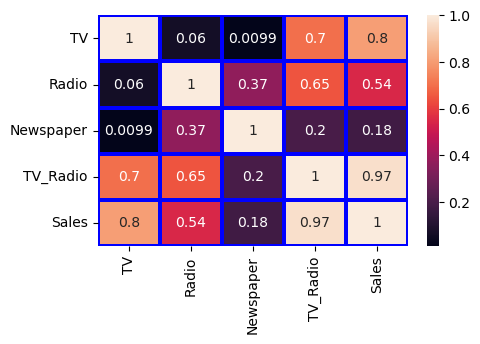

In [84]:
plt.figure(figsize=(5,3))
sns.heatmap(train_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].corr(),  annot=True,linecolor='blue',linewidth=1.5)
plt.show()

In [85]:
test_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].corr()['Sales'].sort_values(ascending=False)

Sales        1.000000
TV_Radio     0.962231
TV           0.739977
Radio        0.659170
Newspaper    0.360390
Name: Sales, dtype: float64

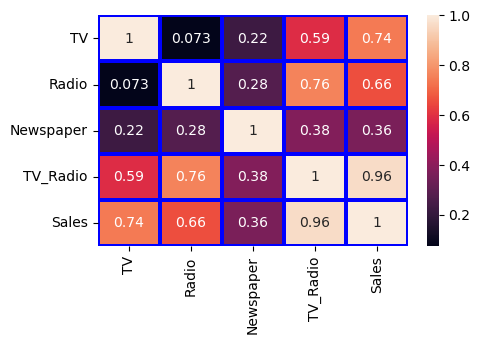

In [86]:
plt.figure(figsize=(5,3))
sns.heatmap(test_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].corr(),  annot=True,linecolor='blue',linewidth=1.5)
plt.show()

- As TV and Radio both have been used for creating the derived feature TV_Radio, we can see some multicollinearity which is not an idel situation for implementing OLS model.
- I am still using this feature to see if there is any improvement happens in terms of predicton.
- I will implement VIF to check the multicollinearity among the predictor variables

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [88]:
train_df_1.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales', 'Date', 'TV_Radio'], dtype='object')

In [89]:
vif_train = pd.DataFrame()
vif_train['Features'] = train_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].columns

In [90]:
# pd.DataFrame(train_df_1.drop(columns=['Date'])).shape[1]

In [91]:
vif_list_train = []
for i in range(pd.DataFrame(train_df_1.drop(columns=['Date'])).shape[1]):
    vif_value = variance_inflation_factor(pd.DataFrame(train_df_1.drop(columns=['Date'])).values, i)
    vif_list_train.append(vif_value)
vif_list_train

[23.981218304257354,
 14.619246687983868,
 3.5969965087973246,
 54.17449317538185,
 7.749020192126337]

In [92]:
vif_train['VIF']=vif_list_train

In [93]:
vif_train.sort_values(by='VIF', ascending=False)

,Features,VIF
3,TV_Radio,54.174493
0,TV,23.981218
1,Radio,14.619247
4,Sales,7.749020
2,Newspaper,3.596997


In [94]:
################# Alternate code for checking VIF #################################

# vif = pd.DataFrame()
# vif['Features'] = train_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].columns
# vif['VIF'] = [variance_inflation_factor(pd.DataFrame(train_df_1.drop(columns=['Date'])).values, i) 
#               for i in range(pd.DataFrame(train_df_1.drop(columns=['Date'])).shape[1])]
# vif['VIF'] = round(vif['VIF'], 2)
# vif = vif.sort_values(by = "VIF", ascending = False)
# vif

In [95]:
# train_df_1.drop(['Newspaper'],axis=1, inplace=True)
# test_df_1.drop(['Newspaper'],axis=1, inplace=True)

In [96]:
#### VIF for Test set

vif_test = pd.DataFrame()
vif_test['Features'] = test_df_1[['TV','Radio','Newspaper','TV_Radio','Sales']].columns

In [97]:
vif_list_test = []
for i in range(pd.DataFrame(test_df_1.drop(columns=['Date'])).shape[1]):
    vif_value = variance_inflation_factor(pd.DataFrame(test_df_1.drop(columns=['Date'])).values, i)
    vif_list_test.append(vif_value)
vif_list_test

[27.28051993040177,
 15.694097326704554,
 3.2859634533068243,
 63.575167813489784,
 5.981897445285364]

In [98]:
vif_test['VIF'] = vif_list_test

In [99]:
vif_test.sort_values(by='VIF', ascending=False)

,Features,VIF
3,TV_Radio,63.575168
0,TV,27.280520
1,Radio,15.694097
4,Sales,5.981897
2,Newspaper,3.285963


- There is a clear indication of Multicollinearity, although I will implement OLS to check the impact on Sales of all the predictor variables

In [100]:
train_df_1.head(3)

,TV,Radio,Newspaper,Sales,Date,TV_Radio
0,230.1,37.8,69.2,22.1,2022-01-08,8697.78
1,44.5,39.3,45.1,10.4,2022-01-15,1748.85
2,17.2,45.9,69.3,9.3,2022-01-22,789.48


In [101]:
test_df_1.head(3)

,TV,Radio,Newspaper,Sales,Date,TV_Radio
140,73.4,17.0,12.9,10.9,2024-09-14,1247.80
141,193.7,35.4,75.6,19.2,2024-09-21,6856.98
142,220.5,33.2,37.9,20.1,2024-09-28,7320.60


In [102]:
#### Splitting into x_train and y_train

x_train_1 = train_df_1[['TV','Radio','Newspaper','TV_Radio']]
y_train_1 = train_df_1[['Sales']]

#### splitting into x_test and y_test
x_test_1 = test_df_1[['TV','Radio','Newspaper','TV_Radio']]
y_test_1 = test_df_1[['Sales']]

In [103]:
x_train_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         140 non-null    float64
 1   Radio      140 non-null    float64
 2   Newspaper  140 non-null    float64
 3   TV_Radio   140 non-null    float64
dtypes: float64(4)
memory usage: 4.5 KB


In [104]:
x_test_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 140 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         60 non-null     float64
 1   Radio      60 non-null     float64
 2   Newspaper  60 non-null     float64
 3   TV_Radio   60 non-null     float64
dtypes: float64(4)
memory usage: 2.0 KB


In [105]:
x_train_num_scaled_1 = scaler.fit_transform(x_train_1)

#### Converting the numpy array, received as the output of scaling done in the previous step, into a dataframe where 
#### the column names of the main dataframe is maintained
x_train_num_scaled_1_df = pd.DataFrame(x_train_num_scaled_1, columns = x_train_1.columns)
x_train_num_scaled_1_df.head()

,TV,Radio,Newspaper,TV_Radio
0,0.998823,0.894869,1.635721,1.520829
1,-1.148661,0.997229,0.563919,-0.562809
2,-1.464536,1.447612,1.640169,-0.850477
3,0.089382,1.133709,1.159859,0.788946
4,0.428398,-0.947609,1.155412,-0.501703


In [106]:
y_train_1.head()

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [107]:
#### Applying the scaler on the test set.
x_test_num_scaled_1 = scaler.transform(x_test_1)

#### Creating the dataframe as done before in the case of train set.
x_test_num_scaled_df_1 = pd.DataFrame(x_test_num_scaled_1, columns = x_test_1.columns)
x_test_num_scaled_df_1.head()

,TV,Radio,Newspaper,TV_Radio
0,-0.814274,-0.524521,-0.868115,-0.713049
1,0.577657,0.731093,1.920349,0.968865
2,0.887746,0.580965,0.243713,1.107882
3,-0.453274,-1.295632,0.088057,-0.908426
4,-0.550466,-0.674649,0.288186,-0.660288


In [108]:
x_test_num_scaled_df_1.index = test_df_1.index
x_test_num_scaled_df_1.head()

,TV,Radio,Newspaper,TV_Radio
140,-0.814274,-0.524521,-0.868115,-0.713049
141,0.577657,0.731093,1.920349,0.968865
142,0.887746,0.580965,0.243713,1.107882
143,-0.453274,-1.295632,0.088057,-0.908426
144,-0.550466,-0.674649,0.288186,-0.660288


In [109]:
y_test_1.head()

,Sales
140,10.9
141,19.2
142,20.1
143,10.4
144,11.4


In [110]:
x_train_const_1 = sm.add_constant(x_train_num_scaled_1_df)

x_train_const_1.head()

,const,TV,Radio,Newspaper,TV_Radio
0,1.0,0.998823,0.894869,1.635721,1.520829
1,1.0,-1.148661,0.997229,0.563919,-0.562809
2,1.0,-1.464536,1.447612,1.640169,-0.850477
3,1.0,0.089382,1.133709,1.159859,0.788946
4,1.0,0.428398,-0.947609,1.155412,-0.501703


#### Third Model

In [111]:
ols_3 = sm.OLS(y_train_1, x_train_const_1).fit()

In [112]:
print(ols_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     938.8
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           1.97e-97
Time:                        09:03:25   Log-Likelihood:                -195.53
No. Observations:                 140   AIC:                             401.1
Df Residuals:                     135   BIC:                             415.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1479      0.084    168.092      0.0

- This model can explain 96.4% of the variability of the dataset as the Adjusted R-Squared value is 96.4%
- The Radio and Newspaper variables have p-value which are greater than 0.05. So Statistically these predictors will be insignificant.
- As of now, I am removing only newspaper and keeping radio to check if there is any development happens.

In [113]:
x_train_const_2 = x_train_const_1.drop(['Newspaper'],axis=1)
x_train_const_2.head()

,const,TV,Radio,TV_Radio
0,1.0,0.998823,0.894869,1.520829
1,1.0,-1.148661,0.997229,-0.562809
2,1.0,-1.464536,1.447612,-0.850477
3,1.0,0.089382,1.133709,0.788946
4,1.0,0.428398,-0.947609,-0.501703


#### Fourth Model

In [114]:
ols_4 = sm.OLS(y_train_1, x_train_const_2).fit()

In [115]:
print(ols_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     1256.
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           6.75e-99
Time:                        09:03:26   Log-Likelihood:                -195.82
No. Observations:                 140   AIC:                             399.6
Df Residuals:                     136   BIC:                             411.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1479      0.084    168.365      0.0

- The Adjusted R-Squared value remains same and we can see that, Radio also has become significant as its p-value became < 0.05

#### Predicting the Train Set using this model ols_4

In [116]:
y_train_hat_1 = ols_4.predict(x_train_const_2)

In [117]:
y_train_hat_1.head()

0    21.717856
1    10.558786
2     9.133978
3    17.620647
4    12.631852
dtype: float64

In [118]:
y_train_1.head()

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [119]:
concat_train_pred_df_1 = pd.DataFrame({
    'Date':train_df['Date'],
    'Actual Value': y_train_1.iloc[:,0],
    'Predicted Value': y_train_hat_1})

concat_train_pred_df_1['Error'] = concat_train_pred_df_1['Actual Value']-concat_train_pred_df_1['Predicted Value']

concat_train_pred_df_1

,Date,Actual Value,Predicted Value,Error
0,2022-01-08,22.1,21.717856,0.382144
1,2022-01-15,10.4,10.558786,-0.158786
2,2022-01-22,9.3,9.133978,0.166022
3,2022-01-29,18.5,17.620647,0.879353
4,2022-02-05,12.9,12.631852,0.268148
...,...,...,...,...
135,2024-08-10,11.6,11.389418,0.210582
136,2024-08-17,9.5,9.364035,0.135965
137,2024-08-24,20.8,21.429400,-0.629400
138,2024-08-31,9.6,9.511933,0.088067


#### Predicting the test set using this model ols_4

In [120]:
x_test_num_scaled_2 = x_test_num_scaled_df_1.drop(['Newspaper'], axis=1)
x_test_num_scaled_2.head()

,TV,Radio,TV_Radio
140,-0.814274,-0.524521,-0.713049
141,0.577657,0.731093,0.968865
142,0.887746,0.580965,1.107882
143,-0.453274,-1.295632,-0.908426
144,-0.550466,-0.674649,-0.660288


In [121]:
y_test_hat_1 = ols_4.predict(sm.add_constant(x_test_num_scaled_2))
y_test_hat_1.head()

140    10.015412
141    18.931604
142    19.892188
143     9.597517
144    10.580125
dtype: float64

In [122]:
y_test_1.head()

,Sales
140,10.9
141,19.2
142,20.1
143,10.4
144,11.4


In [123]:
y_test.iloc[:,0].head()

140    10.9
141    19.2
142    20.1
143    10.4
144    11.4
Name: Sales, dtype: float64

In [124]:
concat_test_pred_df_1 = pd.DataFrame({
    'Date':test_df['Date'],
    'Actual Value': y_test_1.iloc[:,0],
    'Predicted Value': y_test_hat_1})

concat_test_pred_df_1['Error'] = concat_test_pred_df_1['Actual Value']-concat_test_pred_df_1['Predicted Value']

concat_test_pred_df_1.head()

,Date,Actual Value,Predicted Value,Error
140,2024-09-14,10.9,10.015412,0.884588
141,2024-09-21,19.2,18.931604,0.268396
142,2024-09-28,20.1,19.892188,0.207812
143,2024-10-05,10.4,9.597517,0.802483
144,2024-10-12,11.4,10.580125,0.819875


### Residual Analysis for Train and Test Set for OLS_4 model

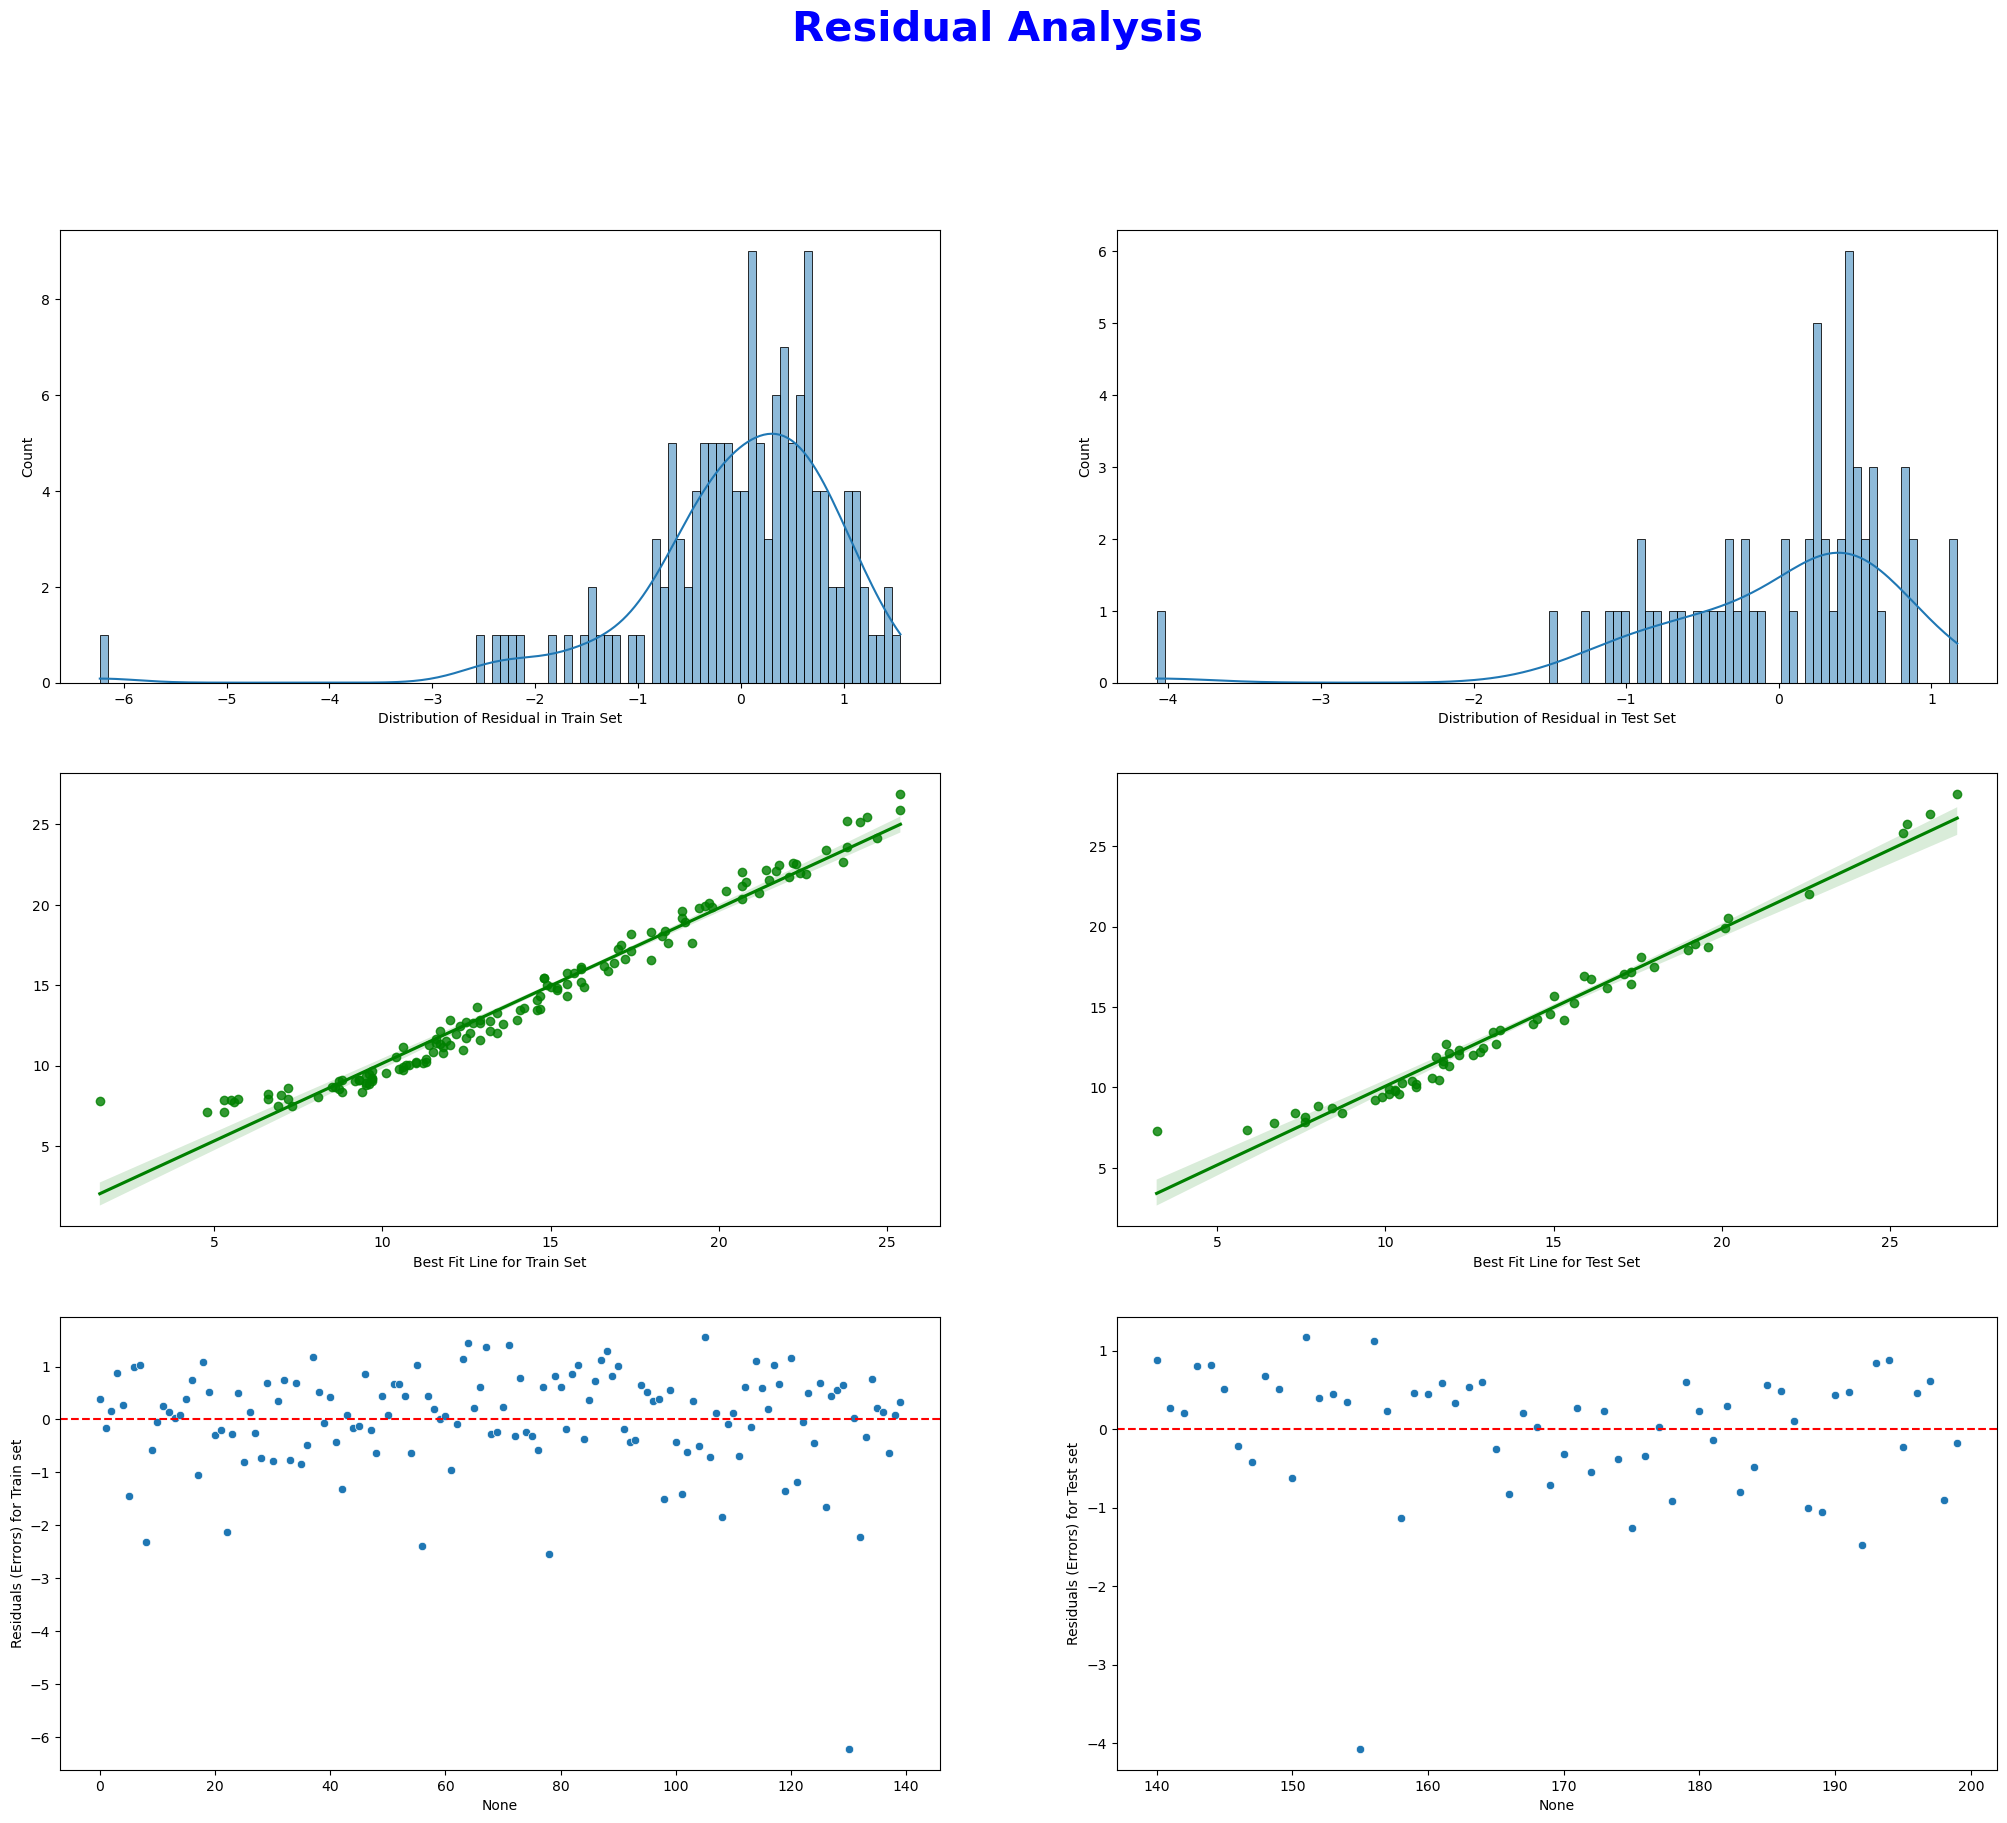

In [125]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25,20))

sns.histplot(x='Error', data=concat_train_pred_df_1, kde=True,bins=100, ax=axes[0,0])
axes[0,0].set_xlabel('Distribution of Residual in Train Set')

sns.histplot(x='Error', data=concat_test_pred_df_1, kde=True,bins=100, ax=axes[0,1])
axes[0,1].set_xlabel('Distribution of Residual in Test Set')

sns.regplot(x=y_train_1, y=y_train_hat_1, color='green', ax=axes[1,0])
axes[1,0].set_xlabel('Best Fit Line for Train Set')

sns.regplot(x=y_test_1, y=y_test_hat_1, color='green', ax=axes[1,1])
axes[1,1].set_xlabel('Best Fit Line for Test Set')

sns.scatterplot(x=concat_train_pred_df_1.index, y=concat_train_pred_df_1['Error'], data=concat_train_pred_df_1, ax=axes[2,0])
axes[2,0].axhline(y=0, color='r', linestyle='--')
axes[2,0].set_ylabel("Residuals (Errors) for Train set")


sns.scatterplot(x=concat_test_pred_df_1.index, y=concat_test_pred_df_1['Error'], data=concat_test_pred_df_1, ax=axes[2,1])
axes[2,1].axhline(y=0, color='r', linestyle='--')
axes[2,1].set_ylabel("Residuals (Errors) for Test set")

fig.suptitle("Residual Analysis", fontsize=30, fontweight='bold', color='blue',ha='center',va='center')
plt.show()

- The Residual is little left skewed but shows normal distribution.
- Homoscedasticity is maintained throughout the model.
- The Best fit line also seems to be defined pretty well for both train and test set.

#### Checking Score and RMSE Error

In [126]:
print("The train set RMSE is: ", np.sqrt(mean_squared_error(y_train_1, y_train_hat_1)))

print("The test set RMSE is: ", np.sqrt(mean_squared_error(y_test_1, y_test_hat_1)))

The train set RMSE is:  0.9799598990552031
The test set RMSE is:  0.8212809916282346


In [127]:
print("The train set R2 score: ", round(r2_score(y_train_1, y_train_hat_1)*100,2))

print("The test set R2 score: ", round(r2_score(y_test_1, y_test_hat_1)*100,2))

The train set R2 score:  96.52
The test set R2 score:  97.39


- The Model Equation will be below:

    Sales = (1.5838 * TV) + (0.3359 * Radio) + (3.7397 * TV_Radio) + 14.1479

- This OLS_4 Model can be considered as our Base Model

In [128]:
# range(1, len(df_copy) + 1)

- Now trying to add a variable for indicating *Trend* in the dataframe.
- In MMM, *Trend* refers to the underlying long-term growth or decline in sales that is not directly driven by your media campaigns.
- Here I can take Moving Average for rolling 4 weeks to take the trend value to check how it goes.
- Otherwise I can do STL decomposition to get the trend and seasonal components to consider as regressor.
- Ideally after regression the model equation will be:

      Sales = Beta_0(constant) + Beta_1 * TV + Beta_2 * Radio + Beta_3 * Newspaper + Beta_4 * Trend_STL + Beta_5 * Seasonality_STL

In [129]:
df_copy_1 = df_copy.copy()
#df_copy_1['Trend'] = range(1, len(df_copy) + 1)
df_copy_1

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,2025-10-04
196,94.2,4.9,8.1,9.7,2025-10-11
197,177.0,9.3,6.4,12.8,2025-10-18
198,283.6,42.0,66.2,25.5,2025-10-25


In [130]:
# df_copy_1['Trend_ma_4'] = (df_copy_1["Sales"].rolling(window=4, center=True).mean())

In [131]:
# df_copy_1.head(10)

In [132]:
# df_copy_1.tail(5)

In [133]:
# df_copy_1.info()

<!-- - Trend_ma_4 has some null values as the trend has been calculated based on 4 point moving average. So, those values will be imputed using immediate consecutive values -->

In [134]:
# df_copy_1[df_copy_1['Trend_ma_4'].isna()]

In [135]:
# df_copy_1[df_copy_1['Trend_ma_4'].isna()].iloc[0:2]

In [136]:
# df_copy_1.iloc[2]['Trend_ma_4']

In [137]:
# df_copy_1[df_copy_1['Trend_ma_4'].isna()].iloc[0:2].fillna(df_copy_1.iloc[2]['Trend_ma_4'])

In [138]:
# df_copy_1.iloc[0:2]

In [139]:
# df_copy_1['Trend_ma_4'] = df_copy_1['Trend_ma_4'].bfill().ffill()

In [140]:
# df_copy_1.head()

In [141]:
# df_copy_1.tail()

In [142]:
# plt.figure(figsize=(8,4))
# sns.lineplot(data=df_copy_1,x='Date',y='Trend_ma_4')
# plt.show()

In [143]:
from statsmodels.tsa.seasonal import STL

stl = STL(df_copy_1["Sales"], period=52)
result = stl.fit()

df_copy_1["trend_stl"] = result.trend
df_copy_1["seasonal_stl"] = result.seasonal
df_copy_1["resid_stl"] = result.resid


In [144]:
df_copy_1

,TV,Radio,Newspaper,Sales,Date,trend_stl,seasonal_stl,resid_stl
0,230.1,37.8,69.2,22.1,2022-01-08,12.965522,9.314083,-0.179604
1,44.5,39.3,45.1,10.4,2022-01-15,13.013751,0.185760,-2.799511
2,17.2,45.9,69.3,9.3,2022-01-22,13.061519,-0.360022,-3.401496
3,151.5,41.3,58.5,18.5,2022-01-29,13.108816,7.441231,-2.050047
4,180.8,10.8,58.4,12.9,2022-02-05,13.155641,-3.285538,3.029897
...,...,...,...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,2025-10-04,13.766989,-6.139088,-0.027901
196,94.2,4.9,8.1,9.7,2025-10-11,13.775310,-4.150624,0.075314
197,177.0,9.3,6.4,12.8,2025-10-18,13.783544,-2.263375,1.279831
198,283.6,42.0,66.2,25.5,2025-10-25,13.791692,8.717208,2.991100


In [146]:
df_copy_1[['TV','Radio','Newspaper','TV_Radio','trend_stl','seasonal_stl','Sales']].corr()['Sales'].sort_values(ascending=False)

Sales           1.000000
TV_Radio        0.963932
seasonal_stl    0.788888
TV              0.782224
Radio           0.576223
Newspaper       0.228299
trend_stl       0.119397
Name: Sales, dtype: float64

In [145]:
#### As in the last model we have seen that using TV_Radio, we got a nice Adjusted R2 score, so here we will take this derived feature into consideration

df_copy_1['TV_Radio'] = df_copy_1['TV']*df_copy_1['Radio']

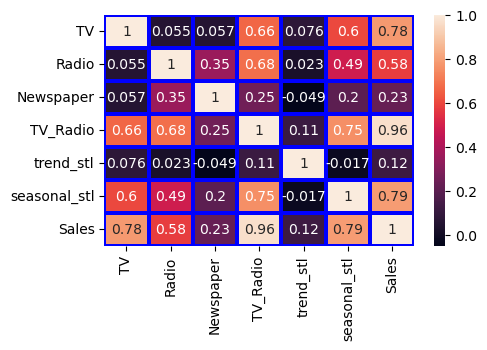

In [147]:
plt.figure(figsize=(5,3))
sns.heatmap(df_copy_1[['TV','Radio','Newspaper','TV_Radio','trend_stl','seasonal_stl','Sales']].corr(), annot=True,linecolor='blue',linewidth=1.5)
plt.show()

#### Splitting into Train and Test Set

In [148]:
train_df_2 = df_copy_1.iloc[0: int(len(df_copy)*0.7)]
train_df_2

,TV,Radio,Newspaper,Sales,Date,trend_stl,seasonal_stl,resid_stl,TV_Radio
0,230.1,37.8,69.2,22.1,2022-01-08,12.965522,9.314083,-0.179604,8697.78
1,44.5,39.3,45.1,10.4,2022-01-15,13.013751,0.185760,-2.799511,1748.85
2,17.2,45.9,69.3,9.3,2022-01-22,13.061519,-0.360022,-3.401496,789.48
3,151.5,41.3,58.5,18.5,2022-01-29,13.108816,7.441231,-2.050047,6256.95
4,180.8,10.8,58.4,12.9,2022-02-05,13.155641,-3.285538,3.029897,1952.64
...,...,...,...,...,...,...,...,...,...
135,48.3,47.0,8.5,11.6,2024-08-10,13.384363,0.341440,-2.125803,2270.10
136,25.6,39.0,9.3,9.5,2024-08-17,13.367315,0.876383,-4.743698,998.40
137,273.7,28.9,59.7,20.8,2024-08-24,13.352081,0.306125,7.141793,7909.93
138,43.0,25.9,20.5,9.6,2024-08-31,13.338978,-3.213402,-0.525576,1113.70


In [149]:
test_df_2 = df_copy_1.iloc[int(len(df_copy)*0.7) :]
test_df_2.head()

,TV,Radio,Newspaper,Sales,Date,trend_stl,seasonal_stl,resid_stl,TV_Radio
140,73.4,17.0,12.9,10.9,2024-09-14,13.320307,-3.300446,0.880139,1247.80
141,193.7,35.4,75.6,19.2,2024-09-21,13.315087,4.676876,1.208036,6856.98
142,220.5,33.2,37.9,20.1,2024-09-28,13.312656,2.555324,4.232020,7320.60
143,104.6,5.7,34.4,10.4,2024-10-05,13.312840,-4.399528,1.486688,596.22
144,96.2,14.8,38.9,11.4,2024-10-12,13.315449,-0.786363,-1.129086,1423.76


In [150]:
x_train_2 = train_df_2[['TV','Radio','TV_Radio','trend_stl','seasonal_stl']]
x_train_2.head()

,TV,Radio,TV_Radio,trend_stl,seasonal_stl
0,230.1,37.8,8697.78,12.965522,9.314083
1,44.5,39.3,1748.85,13.013751,0.185760
2,17.2,45.9,789.48,13.061519,-0.360022
3,151.5,41.3,6256.95,13.108816,7.441231
4,180.8,10.8,1952.64,13.155641,-3.285538


In [151]:
y_train_2 = train_df_2[['Sales']]
y_train_2.head()

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [152]:
x_train_num_scaled_2 = scaler.fit_transform(x_train_2)

In [153]:
x_train_num_scaled_df_2 = pd.DataFrame(x_train_num_scaled_2, columns = x_train_2.columns)
x_train_num_scaled_df_2

,TV,Radio,TV_Radio,trend_stl,seasonal_stl
0,0.998823,0.894869,1.520829,-2.171533,2.692697
1,-1.148661,0.997229,-0.562809,-2.079387,0.056832
2,-1.464536,1.447612,-0.850477,-1.988123,-0.100766
3,0.089382,1.133709,0.788946,-1.897758,2.151898
4,0.428398,-0.947609,-0.501703,-1.808295,-0.945529
...,...,...,...,...,...
135,-1.104693,1.522676,-0.406512,-1.371303,0.101786
136,-1.367344,0.976757,-0.787832,-1.403875,0.256254
137,1.503297,0.287534,1.284592,-1.432980,0.091589
138,-1.166017,0.082814,-0.753259,-1.458015,-0.924699


In [154]:
x_train_const_3 = sm.add_constant(x_train_num_scaled_df_2)
x_train_const_3

,const,TV,Radio,TV_Radio,trend_stl,seasonal_stl
0,1.0,0.998823,0.894869,1.520829,-2.171533,2.692697
1,1.0,-1.148661,0.997229,-0.562809,-2.079387,0.056832
2,1.0,-1.464536,1.447612,-0.850477,-1.988123,-0.100766
3,1.0,0.089382,1.133709,0.788946,-1.897758,2.151898
4,1.0,0.428398,-0.947609,-0.501703,-1.808295,-0.945529
...,...,...,...,...,...,...
135,1.0,-1.104693,1.522676,-0.406512,-1.371303,0.101786
136,1.0,-1.367344,0.976757,-0.787832,-1.403875,0.256254
137,1.0,1.503297,0.287534,1.284592,-1.432980,0.091589
138,1.0,-1.166017,0.082814,-0.753259,-1.458015,-0.924699


#### Fifth Model

In [155]:
ols_5 = sm.OLS(y_train_2, x_train_const_3).fit()

In [156]:
print(ols_5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     834.3
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           4.39e-99
Time:                        09:03:41   Log-Likelihood:                -187.91
No. Observations:                 140   AIC:                             387.8
Df Residuals:                     134   BIC:                             405.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           14.1479      0.080    176.836   

- The Adjusted R2 score has been improved from the previous model (ols_4).
- Already I eliminated Newspaper. Rest all the columns including TV_Radio are statistically significant.
- The Model Equation will be:

    Sales = 14.1479 + 1.4887 * TV + 0.3280 * Radio + 3.4778 * TV_radio + 0.1655 * Trend_STL + 0.4374 * Seasonality_STL

#### Predicting Train using this model

In [157]:
y_train_hat_2 = ols_5.predict(x_train_const_3)
y_train_hat_2

0      22.035705
1      10.488250
2       9.111466
3      18.023620
4      12.017026
         ...    
135    11.406507
136     9.572453
137    20.750490
138     9.173699
139    19.895679
Length: 140, dtype: float64

In [158]:
y_train_2

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
135,11.6
136,9.5
137,20.8
138,9.6


In [159]:
concat_train_pred_df_2 = pd.DataFrame({
    'Date':train_df_2['Date'],
    'Actual Value': y_train_2.iloc[:,0],
    'Predicted Value': y_train_hat_2})

concat_train_pred_df_2['Error'] = concat_train_pred_df_2['Actual Value']-concat_train_pred_df_2['Predicted Value']

concat_train_pred_df_2

,Date,Actual Value,Predicted Value,Error
0,2022-01-08,22.1,22.035705,0.064295
1,2022-01-15,10.4,10.488250,-0.088250
2,2022-01-22,9.3,9.111466,0.188534
3,2022-01-29,18.5,18.023620,0.476380
4,2022-02-05,12.9,12.017026,0.882974
...,...,...,...,...
135,2024-08-10,11.6,11.406507,0.193493
136,2024-08-17,9.5,9.572453,-0.072453
137,2024-08-24,20.8,20.750490,0.049510
138,2024-08-31,9.6,9.173699,0.426301


#### Predicting Test Set

In [160]:
x_test_2 = test_df_2[['TV','Radio','TV_Radio','trend_stl','seasonal_stl']]
x_test_2.head()

,TV,Radio,TV_Radio,trend_stl,seasonal_stl
140,73.4,17.0,1247.80,13.320307,-3.300446
141,193.7,35.4,6856.98,13.315087,4.676876
142,220.5,33.2,7320.60,13.312656,2.555324
143,104.6,5.7,596.22,13.312840,-4.399528
144,96.2,14.8,1423.76,13.315449,-0.786363


In [161]:
y_test_2 = test_df_2[['Sales']]
y_test_2.head()

,Sales
140,10.9
141,19.2
142,20.1
143,10.4
144,11.4


In [162]:
x_test_num_scaled_3 = scaler.transform(x_test_2)
x_test_num_scaled_3[:5]

array([[-0.8142738 , -0.52452119, -0.71304945, -1.49368744, -0.94983309],
       [ 0.57765711,  0.73109314,  0.96886495, -1.50365945,  1.35367213],
       [ 0.88774646,  0.58096534,  1.10788155, -1.50830529,  0.74105973],
       [-0.45327426, -1.29563216, -0.90842592, -1.50795352, -1.26720062],
       [-0.55046644, -0.67464899, -0.66028779, -1.50296857, -0.22387476]])

In [163]:
x_test_num_scaled_df_2 = pd.DataFrame(x_test_num_scaled_3, columns = x_test_2.columns)
x_test_num_scaled_df_2.head()

,TV,Radio,TV_Radio,trend_stl,seasonal_stl
0,-0.814274,-0.524521,-0.713049,-1.493687,-0.949833
1,0.577657,0.731093,0.968865,-1.503659,1.353672
2,0.887746,0.580965,1.107882,-1.508305,0.741060
3,-0.453274,-1.295632,-0.908426,-1.507954,-1.267201
4,-0.550466,-0.674649,-0.660288,-1.502969,-0.223875


In [164]:
x_test_num_scaled_df_2.index = x_test_2.index

In [165]:
y_test_hat_2 = ols_5.predict(sm.add_constant(x_test_num_scaled_df_2))
y_test_hat_2.head(7)

140     9.621063
141    18.960279
142    19.587417
143     9.084884
144    10.464017
145     9.913171
146    13.727554
dtype: float64

In [166]:
y_test_2.head(7)

,Sales
140,10.9
141,19.2
142,20.1
143,10.4
144,11.4
145,10.3
146,13.2


In [167]:
concat_test_pred_df_2 = pd.DataFrame({
    'Date':test_df_2['Date'],
    'Actual Value': y_test_2.iloc[:,0],
    'Predicted Value': y_test_hat_2})

concat_test_pred_df_2['Error'] = concat_test_pred_df_2['Actual Value']-concat_test_pred_df_2['Predicted Value']

concat_test_pred_df_2.head()

,Date,Actual Value,Predicted Value,Error
140,2024-09-14,10.9,9.621063,1.278937
141,2024-09-21,19.2,18.960279,0.239721
142,2024-09-28,20.1,19.587417,0.512583
143,2024-10-05,10.4,9.084884,1.315116
144,2024-10-12,11.4,10.464017,0.935983


#### Residual Analysis

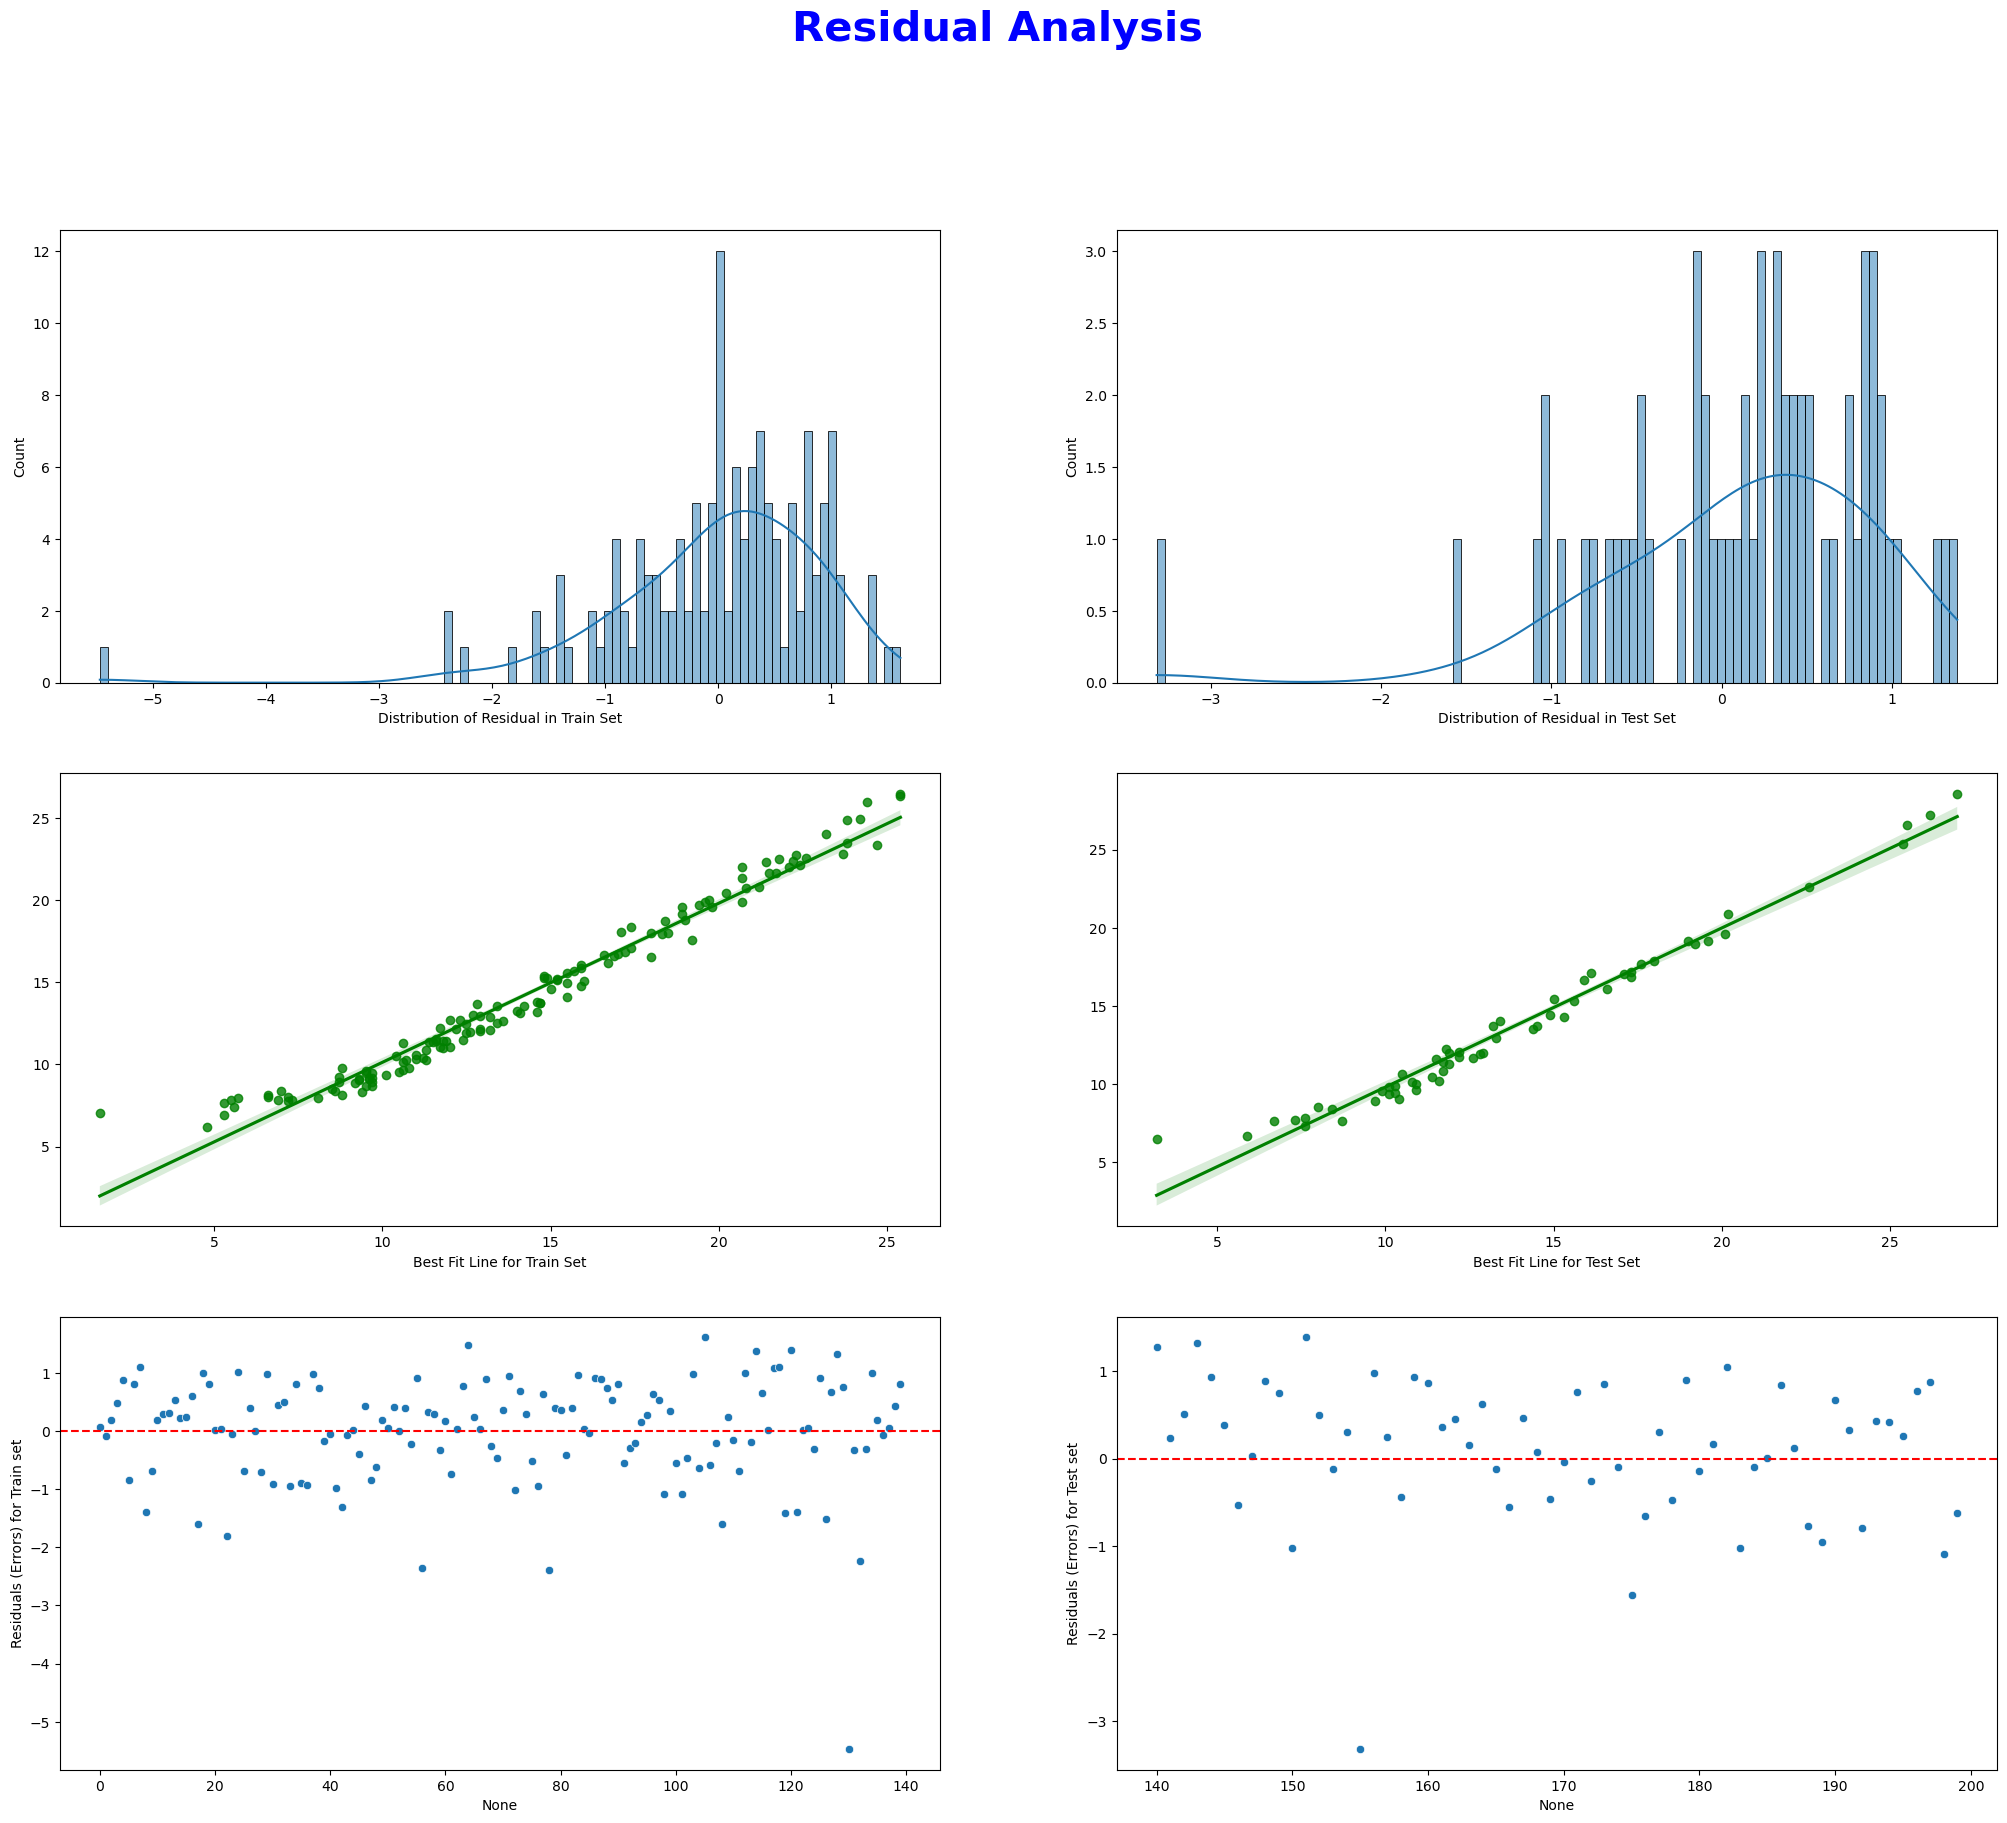

In [168]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25,20))

sns.histplot(x='Error', data=concat_train_pred_df_2, kde=True,bins=100, ax=axes[0,0])
axes[0,0].set_xlabel('Distribution of Residual in Train Set')

sns.histplot(x='Error', data=concat_test_pred_df_2, kde=True,bins=100, ax=axes[0,1])
axes[0,1].set_xlabel('Distribution of Residual in Test Set')

sns.regplot(x=y_train_2, y=y_train_hat_2, color='green', ax=axes[1,0])
axes[1,0].set_xlabel('Best Fit Line for Train Set')

sns.regplot(x=y_test_2, y=y_test_hat_2, color='green', ax=axes[1,1])
axes[1,1].set_xlabel('Best Fit Line for Test Set')

sns.scatterplot(x=concat_train_pred_df_2.index, y=concat_train_pred_df_2['Error'], data=concat_train_pred_df_2, ax=axes[2,0])
axes[2,0].axhline(y=0, color='r', linestyle='--')
axes[2,0].set_ylabel("Residuals (Errors) for Train set")


sns.scatterplot(x=concat_test_pred_df_2.index, y=concat_test_pred_df_2['Error'], data=concat_test_pred_df_2, ax=axes[2,1])
axes[2,1].axhline(y=0, color='r', linestyle='--')
axes[2,1].set_ylabel("Residuals (Errors) for Test set")

fig.suptitle("Residual Analysis", fontsize=30, fontweight='bold', color='blue',ha='center',va='center')
plt.show()


#### Checking RMSE and R2-score

In [169]:
print("The train set RMSE is: ", np.sqrt(mean_squared_error(y_train_2, y_train_hat_2)))

print("The test set RMSE is: ", np.sqrt(mean_squared_error(y_test_2, y_test_hat_2)))

The train set RMSE is:  0.9261317579427037
The test set RMSE is:  0.8091373557449442


In [170]:
print("The train set R2 score: ", round(r2_score(y_train_2, y_train_hat_2)*100,2))

print("The test set R2 score: ", round(r2_score(y_test_2, y_test_hat_2)*100,2))

The train set R2 score:  96.89
The test set R2 score:  97.47


- Future Scope :
  - Koyck Model - Present sales is not only dependent on Independent variables, but also on the last period's Sales valu
  - Distributed Lag Model - Present Sales is dependent on lagged sales as well as lagged version of other Media KPIs and their present values. This is a more generalised model and captures the carry-over effect of all the variables.
  - Thus, the Koyck model is a special type of distributed lag model, which includes the lag value of only the dependent variable.
  - Hierarchical model - On the other hand, uses dummy variables to capture the impact, like content or media. As the dummy variable takes a value of 1 or 0, it signifies the presence of one or the other content or media channel.

In [171]:
df_lag = df_copy.copy()

In [172]:
df_lag.head()

,TV,Radio,Newspaper,Sales,Date
0,230.1,37.8,69.2,22.1,2022-01-08
1,44.5,39.3,45.1,10.4,2022-01-15
2,17.2,45.9,69.3,9.3,2022-01-22
3,151.5,41.3,58.5,18.5,2022-01-29
4,180.8,10.8,58.4,12.9,2022-02-05


In [173]:
df_lag['TV_lag1'] = df_lag['TV'].shift(1)                              # One week Lag for TV
df_lag['TV_lag2'] = df_lag['TV'].shift(2)                              # Two weeks lag for TV
df_lag['TV_lag3'] = df_lag['TV'].shift(3)                              # Three weeks lag for TV
df_lag['Radio_lag1'] = df_lag['Radio'].shift(1)                        # One week lag for Radio
df_lag['Radio_lag2'] = df_lag['Radio'].shift(2)                        # Two weeks lag for Radio
df_lag['Newspaper_lag1'] = df_lag['Newspaper'].shift(1)                # One week lag for Newspaper
df_lag['Newspaper_lag2'] = df_lag['Newspaper'].shift(2)                # Two weeks lag for Newspaper
df_lag['Sales_lag1'] = df_lag['Sales'].shift(1)                        # One wek lag for Sales

In [174]:
df_lag.head(10)

,TV,Radio,Newspaper,Sales,Date,TV_lag1,TV_lag2,TV_lag3,Radio_lag1,Radio_lag2,Newspaper_lag1,Newspaper_lag2,Sales_lag1
0,230.1,37.8,69.2,22.1,2022-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,44.5,39.3,45.1,10.4,2022-01-15,230.1,NaN,NaN,37.8,NaN,69.2,NaN,22.1
2,17.2,45.9,69.3,9.3,2022-01-22,44.5,230.1,NaN,39.3,37.8,45.1,69.2,10.4
3,151.5,41.3,58.5,18.5,2022-01-29,17.2,44.5,230.1,45.9,39.3,69.3,45.1,9.3
4,180.8,10.8,58.4,12.9,2022-02-05,151.5,17.2,44.5,41.3,45.9,58.5,69.3,18.5
5,8.7,48.9,75.0,7.2,2022-02-12,180.8,151.5,17.2,10.8,41.3,58.4,58.5,12.9
6,57.5,32.8,23.5,11.8,2022-02-19,8.7,180.8,151.5,48.9,10.8,75.0,58.4,7.2
7,120.2,19.6,11.6,13.2,2022-02-26,57.5,8.7,180.8,32.8,48.9,23.5,75.0,11.8
8,8.6,2.1,1.0,4.8,2022-03-05,120.2,57.5,8.7,19.6,32.8,11.6,23.5,13.2
9,199.8,2.6,21.2,10.6,2022-03-12,8.6,120.2,57.5,2.1,19.6,1.0,11.6,4.8


- As we can see there are few null values introduced with the introduction of lagged columns
- These null values will be imputed in the next step
- All these lagged values will be used in modelling t see if any of them is significant and till which lag the significance is present

#### Null Imputaion

- As we can see that few lagged value is null, which means that in those weeks, the advertisement or campaign activity hasn't started. So for this experimental purpose, we are dropping those columns.

In [175]:
df_model = df_lag.dropna()

In [176]:
df_model

,TV,Radio,Newspaper,Sales,Date,TV_lag1,TV_lag2,TV_lag3,Radio_lag1,Radio_lag2,Newspaper_lag1,Newspaper_lag2,Sales_lag1
3,151.5,41.3,58.5,18.5,2022-01-29,17.2,44.5,230.1,45.9,39.3,69.3,45.1,9.3
4,180.8,10.8,58.4,12.9,2022-02-05,151.5,17.2,44.5,41.3,45.9,58.5,69.3,18.5
5,8.7,48.9,75.0,7.2,2022-02-12,180.8,151.5,17.2,10.8,41.3,58.4,58.5,12.9
6,57.5,32.8,23.5,11.8,2022-02-19,8.7,180.8,151.5,48.9,10.8,75.0,58.4,7.2
7,120.2,19.6,11.6,13.2,2022-02-26,57.5,8.7,180.8,32.8,48.9,23.5,75.0,11.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,2025-10-04,149.7,166.8,17.2,35.6,42.0,6.0,3.6,17.3
196,94.2,4.9,8.1,9.7,2025-10-11,38.2,149.7,166.8,3.7,35.6,13.8,6.0,7.6
197,177.0,9.3,6.4,12.8,2025-10-18,94.2,38.2,149.7,4.9,3.7,8.1,13.8,9.7
198,283.6,42.0,66.2,25.5,2025-10-25,177.0,94.2,38.2,9.3,4.9,6.4,8.1,12.8


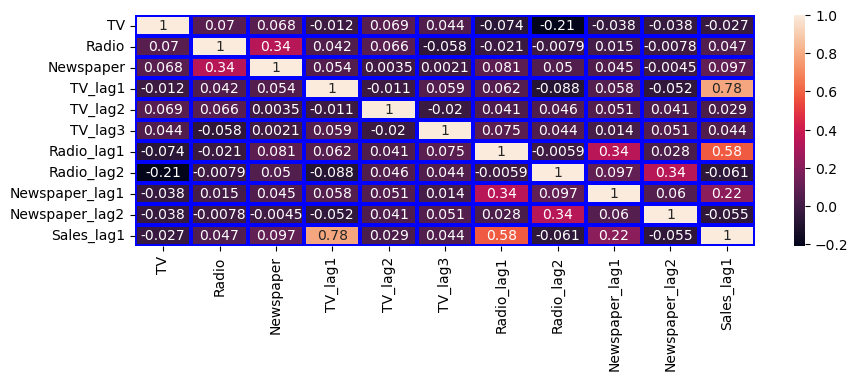

In [178]:
plt.figure(figsize=(10,3))
sns.heatmap(df_model[['TV','Radio','Newspaper','TV_lag1','TV_lag2','TV_lag3','Radio_lag1',
                     'Radio_lag2','Newspaper_lag1','Newspaper_lag2','Sales_lag1']].corr(), annot=True,linecolor='blue',linewidth=1.5)
plt.show()

In [181]:
df_model[['TV','Radio','Newspaper','TV_lag1','TV_lag2','TV_lag3','Radio_lag1',
                     'Radio_lag2','Newspaper_lag1','Newspaper_lag2','Sales_lag1','Sales']].corr()['Sales'].sort_values(ascending=False)

Sales             1.000000
TV                0.780043
Radio             0.591521
Newspaper         0.231053
TV_lag2           0.048935
TV_lag1           0.022664
TV_lag3           0.019708
Sales_lag1        0.011735
Newspaper_lag2   -0.014348
Newspaper_lag1   -0.052210
Radio_lag1       -0.056342
Radio_lag2       -0.151363
Name: Sales, dtype: float64

In [189]:
VIF_df = pd.DataFrame()
VIF_df['Features'] = df_model[['TV','Radio','Newspaper','TV_lag1','TV_lag2','TV_lag3','Radio_lag1',
                     'Radio_lag2','Newspaper_lag1','Newspaper_lag2','Sales_lag1']].columns

In [190]:
VIF_List = []

for i in range(pd.DataFrame(df_model.drop(columns=['Date','Sales'])).shape[1]):
    vif_value = variance_inflation_factor(pd.DataFrame(df_model.drop(columns=['Date'])).values, i)
    VIF_List.append(vif_value)
VIF_List

[26.23117298014131,
 13.789540588290125,
 3.3701020709551512,
 73.95933467437753,
 25.780736161114014,
 3.7208128693126246,
 3.7243241737719894,
 13.917588138473926,
 3.9712552033289596,
 3.386489318307013,
 3.348902866322914]

In [191]:
VIF_df['VIF']=VIF_List

VIF_df.sort_values(by='VIF',ascending=False)

,Features,VIF
3,TV_lag1,73.959335
0,TV,26.231173
4,TV_lag2,25.780736
7,Radio_lag2,13.917588
1,Radio,13.789541
8,Newspaper_lag1,3.971255
6,Radio_lag1,3.724324
5,TV_lag3,3.720813
9,Newspaper_lag2,3.386489
2,Newspaper,3.370102


- As we can see here few features have VIF value < 5 and few have pretty high value.
- Although we can drop those values, as of now we will keep thos evalues for checking the result